# Physically Informed Building Clustering for TD3 Development-Panel Selection

This notebook selects controller-independent CityLearn building representatives for TD3 hyperparameter development. The primary clustering uses physical descriptors computed from the **development interval only**. TD3 rewards, policy performance, transfer results, and the final test interval are not used.

## Outputs

- validated physical descriptor table;
- K-means cluster-number diagnostics;
- initialization and day-bootstrap stability;
- hierarchical-clustering sensitivity;
- true within-cluster medoids;
- overall portfolio medoid;
- PCA visualization for interpretation only;
- supplementary shape-normalized load analysis;
- exported development-panel files.

> Clustering is used only as a principled building-sampling procedure. Cluster labels are not treated as intrinsic building classes.


## 1. Imports and environment compatibility

Compatible with Python 3.7, NumPy 1.21.6, pandas 1.3.5, SciPy 1.7.3, Matplotlib 3.5.3, Seaborn 0.11.2, and scikit-learn 1.0.2.


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import pdist, squareform
from scipy.stats import zscore
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import RobustScaler
from matplotlib import ticker

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
sns.set_context('notebook')

RANDOM_STATE = 0
EPSILON = 1e-8


c:\Users\Umair\anaconda3\envs\marlin23\lib\site-packages\seaborn\rcmod.py:400: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(mpl.__version__) >= "3.0":
c:\Users\Umair\anaconda3\envs\marlin23\lib\site-packages\setuptools\_distutils\version.py:346: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)


## 2. Configuration

Run the column-inspection cells before setting `PV_COLUMN`. `PV_SIGN` must convert stored PV data to positive physical PV generation. If the CSV contains a normalized per-kW PV profile, multiply by each building's installed PV capacity before clustering.


In [2]:
from pathlib import Path


# --------------------------------------------------------------------------
# Dataset and schema paths
# --------------------------------------------------------------------------
DATA_PATH = Path(
    r'D:\Research\Citylearn_related\Citylearn_data\data\citylearn_challenge_2022_phase_all'
)

SCHEMA_PATH = DATA_PATH / 'schema.json'

BUILDING_IDS = list(range(1, 18))


# --------------------------------------------------------------------------
# Development interval
# --------------------------------------------------------------------------
# Inclusive indices. The final test interval must remain excluded from
# descriptor extraction, clustering, and representative-building selection.
DEVELOPMENT_START = 0
DEVELOPMENT_END = 7671


# --------------------------------------------------------------------------
# Building CSV columns
# --------------------------------------------------------------------------
LOAD_COLUMN = 'Equipment Electric Power [kWh]'

# This is a normalized PV-generation profile in W/kW. It must be multiplied
# by each building's PV nominal power from schema.json and divided by 1000.
PV_COLUMN = 'Solar Generation [W/kW]'

# One-hour simulation time step.
TIME_STEP_HOURS = 1.0


# --------------------------------------------------------------------------
# Optional battery metadata
# --------------------------------------------------------------------------
# Provide a CSV path if battery capacity or nominal power differs by building.
# Expected columns:
# building_id, battery_capacity_kwh, battery_nominal_power_kw
BATTERY_METADATA_PATH = None


# --------------------------------------------------------------------------
# K-means and cluster-validation settings
# --------------------------------------------------------------------------
# Candidate numbers of clusters to evaluate.
K_VALUES = list(range(2, 6))

# Number of independent centroid initializations within each K-means fit.
KMEANS_N_INIT = 50

# Maximum number of iterations for each K-means initialization.
KMEANS_MAX_ITER = 500

# Number of complete K-means repetitions used to assess sensitivity to
# random initialization.
N_INITIALIZATION_REPEATS = 50

# Number of complete-day bootstrap samples used to assess temporal stability.
N_DAY_BOOTSTRAPS = 100

# Absolute Spearman-correlation threshold for flagging potentially
# redundant physical descriptors.
REDUNDANCY_THRESHOLD = 0.95


# --------------------------------------------------------------------------
# Output directory
# --------------------------------------------------------------------------
OUTPUT_DIR = Path('building_clustering_outputs')
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# --------------------------------------------------------------------------
# Basic configuration checks
# --------------------------------------------------------------------------
if not DATA_PATH.is_dir():
    raise FileNotFoundError(
        'Dataset directory does not exist: {}'.format(DATA_PATH)
    )

if not SCHEMA_PATH.is_file():
    raise FileNotFoundError(
        'CityLearn schema does not exist: {}'.format(SCHEMA_PATH)
    )

if DEVELOPMENT_START < 0:
    raise ValueError(
        'DEVELOPMENT_START must be non-negative.'
    )

if DEVELOPMENT_END < DEVELOPMENT_START:
    raise ValueError(
        'DEVELOPMENT_END must be greater than or equal to '
        'DEVELOPMENT_START.'
    )

if TIME_STEP_HOURS <= 0.0:
    raise ValueError(
        'TIME_STEP_HOURS must be greater than zero.'
    )


print('Dataset directory :', DATA_PATH)
print('Schema file       :', SCHEMA_PATH)
print(
    'Development range : {} to {} inclusive'.format(
        DEVELOPMENT_START,
        DEVELOPMENT_END
    )
)
print(
    'Development hours :',
    DEVELOPMENT_END - DEVELOPMENT_START + 1
)
print('Output directory  :', OUTPUT_DIR.resolve())

Dataset directory : D:\Research\Citylearn_related\Citylearn_data\data\citylearn_challenge_2022_phase_all
Schema file       : D:\Research\Citylearn_related\Citylearn_data\data\citylearn_challenge_2022_phase_all\schema.json
Development range : 0 to 7671 inclusive
Development hours : 7672
Output directory  : C:\Users\Umair\Desktop\Ongoing_research\Summer\New folder\building_clustering_outputs


## 3. Discover files and inspect columns

This prevents silent use of the wrong load or PV variable.


In [3]:
# --------------------------------------------------------------------------
# Validate dataset files and inspect the building CSV structure
# --------------------------------------------------------------------------

if not DATA_PATH.is_dir():
    raise FileNotFoundError(
        'Dataset directory does not exist: {}'.format(
            DATA_PATH
        )
    )

if not SCHEMA_PATH.is_file():
    raise FileNotFoundError(
        'CityLearn schema file does not exist: {}'.format(
            SCHEMA_PATH
        )
    )


# Build and validate paths for all building CSV files.
file_paths = {}
missing_files = []

for building_id in BUILDING_IDS:
    file_path = (
        DATA_PATH
        / 'Building_{}.csv'.format(building_id)
    )

    file_paths[building_id] = file_path

    if not file_path.is_file():
        missing_files.append(
            str(file_path)
        )

if missing_files:
    raise FileNotFoundError(
        'The following building files are missing:\n{}'.format(
            '\n'.join(missing_files)
        )
    )


# Read a short sample from the first building.
sample_building_id = BUILDING_IDS[0]
sample_file = file_paths[sample_building_id]

sample = pd.read_csv(
    sample_file,
    nrows=5
)


# Validate the configured load and PV columns.
required_columns = [
    LOAD_COLUMN,
    PV_COLUMN
]

missing_columns = [
    column
    for column in required_columns
    if column not in sample.columns
]

if missing_columns:
    raise KeyError(
        'The sample building file is missing the configured '
        'columns: {}.\nAvailable columns: {}'.format(
            missing_columns,
            sample.columns.tolist()
        )
    )


# Display the inspected file and available columns.
print(
    'Sample building file:',
    sample_file
)

print('\nAvailable columns:')

for column in sample.columns:
    print(
        '  - {!r}'.format(column)
    )

print('\nConfigured physical columns:')
print(
    '  Load column:',
    LOAD_COLUMN
)
print(
    '  PV profile column:',
    PV_COLUMN
)

print('\nSample data:')
display(sample)


# Display basic values from the selected columns.
print('\nLoad-column sample values:')
print(
    sample[LOAD_COLUMN].to_list()
)

print('\nNormalized PV-profile sample values:')
print(
    sample[PV_COLUMN].to_list()
)


print(
    '\nValidation successful: all {} building files, '
    'the schema file, and the configured load/PV columns '
    'are available.'.format(
        len(BUILDING_IDS)
    )
)

print(
    '\nImportant: the PV column is expressed in W/kW. '
    'The next preprocessing cell must multiply this profile '
    'by each building PV nominal power and divide by 1000 '
    'to obtain hourly building-level PV energy in kWh.'
)

Sample building file: D:\Research\Citylearn_related\Citylearn_data\data\citylearn_challenge_2022_phase_all\Building_1.csv

Available columns:
  - 'Month'
  - 'Hour'
  - 'Day Type'
  - 'Daylight Savings Status'
  - 'Indoor Temperature [C]'
  - 'Average Unmet Cooling Setpoint Difference [C]'
  - 'Indoor Relative Humidity [%]'
  - 'Equipment Electric Power [kWh]'
  - 'DHW Heating [kWh]'
  - 'Cooling Load [kWh]'
  - 'Heating Load [kWh]'
  - 'Solar Generation [W/kW]'

Configured physical columns:
  Load column: Equipment Electric Power [kWh]
  PV profile column: Solar Generation [W/kW]

Sample data:


,Month,Hour,Day Type,Daylight Savings Status,Indoor Temperature [C],Average Unmet Cooling Setpoint Difference [C],Indoor Relative Humidity [%],Equipment Electric Power [kWh],DHW Heating [kWh],Cooling Load [kWh],Heating Load [kWh],Solar Generation [W/kW]
0,7.0,24.0,7.0,0,NaN,NaN,NaN,2.275800,0,0,0,0.0
1,8.0,1.0,1.0,0,NaN,NaN,NaN,0.851167,0,0,0,0.0
2,8.0,2.0,1.0,0,NaN,NaN,NaN,0.834600,0,0,0,0.0
3,8.0,3.0,1.0,0,NaN,NaN,NaN,0.838167,0,0,0,0.0
4,8.0,4.0,1.0,0,NaN,NaN,NaN,1.478433,0,0,0,0.0



Load-column sample values:
[2.2758, 0.8511666666666671, 0.8346000000000005, 0.8381666666666678, 1.478433333333334]

Normalized PV-profile sample values:
[0.0, 0.0, 0.0, 0.0, 0.0]

Validation successful: all 17 building files, the schema file, and the configured load/PV columns are available.

Important: the PV column is expressed in W/kW. The next preprocessing cell must multiply this profile by each building PV nominal power and divide by 1000 to obtain hourly building-level PV energy in kWh.


## 4. Load and validate development-period data

The notebook stops on missing columns, nonnumeric values, nonfinite values, negative physical energy, unequal series lengths, or an invalid development interval.


In [4]:
# --------------------------------------------------------------------------
# Load schema and extract building PV nominal powers
# --------------------------------------------------------------------------

if LOAD_COLUMN is None or PV_COLUMN is None:
    raise ValueError(
        'Set both LOAD_COLUMN and PV_COLUMN explicitly.'
    )

if not SCHEMA_PATH.is_file():
    raise FileNotFoundError(
        'CityLearn schema was not found: {}'.format(
            SCHEMA_PATH
        )
    )

with open(
    SCHEMA_PATH,
    'r',
    encoding='utf-8'
) as file:
    schema = json.load(file)


pv_nominal_power = {}

for building_id in BUILDING_IDS:
    building_name = 'Building_{}'.format(
        building_id
    )

    try:
        nominal_power_kw = schema[
            'buildings'
        ][
            building_name
        ][
            'pv'
        ][
            'attributes'
        ][
            'nominal_power'
        ]

    except KeyError as error:
        raise KeyError(
            'Could not find PV nominal power for {}. '
            'Expected schema path: '
            'buildings -> {} -> pv -> attributes '
            '-> nominal_power.'.format(
                building_name,
                building_name
            )
        ) from error

    nominal_power_kw = float(
        nominal_power_kw
    )

    if (
        not np.isfinite(nominal_power_kw)
        or nominal_power_kw < 0.0
    ):
        raise ValueError(
            'Invalid PV nominal power for {}: {}'.format(
                building_name,
                nominal_power_kw
            )
        )

    pv_nominal_power[building_id] = (
        nominal_power_kw
    )


pv_power_table = pd.DataFrame({
    'building_id': BUILDING_IDS,
    'pv_nominal_power_kw': [
        pv_nominal_power[building_id]
        for building_id in BUILDING_IDS
    ]
}).set_index('building_id')

print('PV nominal powers extracted from schema:')
display(pv_power_table)


# --------------------------------------------------------------------------
# Load and convert building load and PV data
# --------------------------------------------------------------------------

raw_data = {}
full_lengths = {}

for building_id in BUILDING_IDS:
    frame = pd.read_csv(
        file_paths[building_id]
    )

    required_columns = [
        LOAD_COLUMN,
        PV_COLUMN
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in frame.columns
    ]

    if missing_columns:
        raise KeyError(
            'Building {} is missing columns: {}'.format(
                building_id,
                missing_columns
            )
        )

    load = pd.to_numeric(
        frame[LOAD_COLUMN],
        errors='coerce'
    ).to_numpy(dtype=float)

    solar_generation_w_per_kw = pd.to_numeric(
        frame[PV_COLUMN],
        errors='coerce'
    ).to_numpy(dtype=float)

    nominal_power_kw = pv_nominal_power[
        building_id
    ]

    # Convert normalized PV profile from W/kW to actual hourly
    # building-level PV energy in kWh.
    pv = (
        solar_generation_w_per_kw
        * nominal_power_kw
        * TIME_STEP_HOURS
        / 1000.0
    )


    # ----------------------------------------------------------------------
    # Data-quality checks
    # ----------------------------------------------------------------------

    if not np.all(np.isfinite(load)):
        raise ValueError(
            'Nonfinite load values found in Building {}.'.format(
                building_id
            )
        )

    if not np.all(
        np.isfinite(
            solar_generation_w_per_kw
        )
    ):
        raise ValueError(
            'Nonfinite normalized PV values found in '
            'Building {}.'.format(
                building_id
            )
        )

    if not np.all(np.isfinite(pv)):
        raise ValueError(
            'Nonfinite converted PV values found in '
            'Building {}.'.format(
                building_id
            )
        )

    if load.min() < -EPSILON:
        raise ValueError(
            'Negative load found in Building {}. '
            'Verify LOAD_COLUMN.'.format(
                building_id
            )
        )

    if solar_generation_w_per_kw.min() < -EPSILON:
        raise ValueError(
            'Negative normalized PV profile found in '
            'Building {}. Verify the source data.'.format(
                building_id
            )
        )

    if pv.min() < -EPSILON:
        raise ValueError(
            'Negative converted PV generation found in '
            'Building {}.'.format(
                building_id
            )
        )

    # Sanity check for hourly PV generation.
    if (
        nominal_power_kw > 0.0
        and pv.max()
        > 1.5 * nominal_power_kw * TIME_STEP_HOURS
    ):
        raise ValueError(
            'Converted PV generation appears inconsistent '
            'for Building {}. '
            'Peak PV={:.4f} kWh per time step; '
            'nominal power={:.4f} kW.'.format(
                building_id,
                pv.max(),
                nominal_power_kw
            )
        )

    if len(load) != len(pv):
        raise ValueError(
            'Load and PV lengths differ for Building {}: '
            'load={}, PV={}.'.format(
                building_id,
                len(load),
                len(pv)
            )
        )


    # ----------------------------------------------------------------------
    # Select the development interval only
    # ----------------------------------------------------------------------

    full_lengths[building_id] = len(load)

    if (
        DEVELOPMENT_START < 0
        or DEVELOPMENT_END >= len(load)
    ):
        raise IndexError(
            'Development interval [{}, {}] is invalid '
            'for Building {} with {} rows.'.format(
                DEVELOPMENT_START,
                DEVELOPMENT_END,
                building_id,
                len(load)
            )
        )

    selection = slice(
        DEVELOPMENT_START,
        DEVELOPMENT_END + 1
    )

    raw_data[building_id] = {
        'load': load[selection].copy(),
        'pv': pv[selection].copy(),
        'solar_generation_w_per_kw':
            solar_generation_w_per_kw[
                selection
            ].copy(),
        'pv_nominal_power_kw':
            nominal_power_kw
    }


# --------------------------------------------------------------------------
# Cross-building consistency checks
# --------------------------------------------------------------------------

if len(set(full_lengths.values())) != 1:
    raise ValueError(
        'Building time-series lengths differ: {}'.format(
            full_lengths
        )
    )

N_DEVELOPMENT_HOURS = (
    DEVELOPMENT_END
    - DEVELOPMENT_START
    + 1
)

for building_id in BUILDING_IDS:
    if (
        len(raw_data[building_id]['load'])
        != N_DEVELOPMENT_HOURS
    ):
        raise ValueError(
            'Unexpected development-period length for '
            'Building {}.'.format(
                building_id
            )
        )


print(
    'Buildings loaded:',
    len(raw_data)
)

print(
    'Development hours:',
    N_DEVELOPMENT_HOURS
)

print(
    'Development days:',
    N_DEVELOPMENT_HOURS
    / (24.0 / TIME_STEP_HOURS)
)

print(
    'PV conversion applied: '
    'W/kW × nominal power (kW) × time-step duration (h) / 1000'
)

PV nominal powers extracted from schema:


,pv_nominal_power_kw
building_id,
1,4.0
2,4.0
3,4.0
4,5.0
5,4.0
6,4.0
7,4.0
8,4.0
9,4.0


Buildings loaded: 17
Development hours: 7672
Development days: 319.6666666666667
PV conversion applied: W/kW × nominal power (kW) × time-step duration (h) / 1000


## 5. Check physical scales and signs

Review this table before continuing. Very small or identical PV values may indicate normalized irradiance or a per-kW PV profile rather than actual building PV generation.


In [5]:
# --------------------------------------------------------------------------
# Verify physical scales after converting PV from W/kW to hourly kWh
# --------------------------------------------------------------------------

scale_records = []

for building_id in BUILDING_IDS:
    building_data = raw_data[building_id]

    load = np.asarray(
        building_data['load'],
        dtype=float
    )

    pv = np.asarray(
        building_data['pv'],
        dtype=float
    )

    nominal_power_kw = float(
        building_data['pv_nominal_power_kw']
    )

    if load.shape != pv.shape:
        raise ValueError(
            'Load and PV arrays have different shapes for '
            'Building {}: load={}, PV={}.'.format(
                building_id,
                load.shape,
                pv.shape
            )
        )

    if load.size == 0:
        raise ValueError(
            'Building {} contains no development-period data.'.format(
                building_id
            )
        )

    if not np.all(np.isfinite(load)):
        raise ValueError(
            'Building {} contains nonfinite load values.'.format(
                building_id
            )
        )

    if not np.all(np.isfinite(pv)):
        raise ValueError(
            'Building {} contains nonfinite converted PV values.'.format(
                building_id
            )
        )

    if load.min() < -EPSILON:
        raise ValueError(
            'Building {} contains negative physical load.'.format(
                building_id
            )
        )

    if pv.min() < -EPSILON:
        raise ValueError(
            'Building {} contains negative physical PV generation.'.format(
                building_id
            )
        )

    net_demand_without_storage = load - pv
    baseline_grid_import = np.maximum(
        net_demand_without_storage,
        0.0
    )
    baseline_grid_export = np.maximum(
        -net_demand_without_storage,
        0.0
    )

    total_load_kwh = float(load.sum())
    total_pv_kwh = float(pv.sum())

    scale_records.append({
        'building_id': building_id,
        'pv_nominal_power_kw': nominal_power_kw,

        'load_mean_kwh':
            float(load.mean()),
        'load_peak_kwh':
            float(load.max()),
        'load_total_kwh':
            total_load_kwh,

        'pv_mean_kwh':
            float(pv.mean()),
        'pv_peak_kwh':
            float(pv.max()),
        'pv_total_kwh':
            total_pv_kwh,

        'pv_to_load_ratio':
            total_pv_kwh
            / (total_load_kwh + EPSILON),

        'baseline_grid_import_kwh':
            float(baseline_grid_import.sum()),

        'baseline_grid_export_kwh':
            float(baseline_grid_export.sum()),

        'pv_surplus_frequency':
            float(
                (
                    net_demand_without_storage < 0.0
                ).mean()
            )
    })


scale_checks = (
    pd.DataFrame(scale_records)
    .set_index('building_id')
)

if scale_checks.isna().any().any():
    raise ValueError(
        'The physical-scale table contains missing values.'
    )

if not np.all(
    np.isfinite(
        scale_checks.to_numpy(dtype=float)
    )
):
    raise ValueError(
        'The physical-scale table contains nonfinite values.'
    )


print(
    'Physical scale checks after converting '
    'Solar Generation [W/kW] to hourly PV energy '
)

display(
    scale_checks.round(4)
)

Physical scale checks after converting Solar Generation [W/kW] to hourly PV energy 


,pv_nominal_power_kw,load_mean_kwh,load_peak_kwh,load_total_kwh,pv_mean_kwh,pv_peak_kwh,pv_total_kwh,pv_to_load_ratio,baseline_grid_import_kwh,baseline_grid_export_kwh,pv_surplus_frequency
building_id,,,,,,,,,,,
1,4.0,1.1737,7.9875,9004.3541,0.7960,3.9050,6106.8231,0.6782,6065.4898,3167.9587,0.2885
2,4.0,0.9959,6.8431,7640.2615,0.5810,3.1443,4457.7375,0.5835,5503.9496,2321.4257,0.2690
3,4.0,0.7597,6.1013,5828.4246,0.6222,3.3748,4773.6810,0.8190,3896.8829,2842.1393,0.3064
4,5.0,1.0827,5.9059,8306.2960,0.6531,3.5302,5010.7087,0.6032,4796.4045,1500.8172,0.2280
5,4.0,0.9485,4.9388,7276.7567,0.6624,3.2732,5082.1769,0.6984,4164.7521,1970.1723,0.2974
6,4.0,1.1472,6.7906,8800.9621,0.7093,3.5211,5441.5678,0.6183,6286.2568,2926.8625,0.2827
7,4.0,0.9376,7.2398,7193.3629,0.7741,3.8225,5938.8851,0.8256,4211.1244,2956.6467,0.2509
8,4.0,0.9443,7.2682,7244.9405,0.7407,3.5561,5682.5060,0.7843,4803.6821,3241.2476,0.3110
9,4.0,0.7758,5.1916,5952.1151,0.6167,3.3442,4731.1955,0.7949,4190.0314,2969.1118,0.2952


## 6. Optional battery metadata

Battery-relative descriptors are important when capacities or nominal powers differ. Constant battery descriptors should not be used in clustering.


In [6]:
# --------------------------------------------------------------------------
# Extract battery metadata from the CityLearn experiment schema
# --------------------------------------------------------------------------

battery_records = []

for building_id in BUILDING_IDS:
    building_name = 'Building_{}'.format(building_id)

    if building_name not in schema['buildings']:
        raise KeyError(
            'Building configuration not found in schema: {}'.format(
                building_name
            )
        )

    building_configuration = schema['buildings'][building_name]

    # CityLearn schemas commonly use "electrical_storage".
    # Retain "battery" as a fallback for custom schemas.
    if 'electrical_storage' in building_configuration:
        storage_configuration = building_configuration[
            'electrical_storage'
        ]
    elif 'battery' in building_configuration:
        storage_configuration = building_configuration[
            'battery'
        ]
    else:
        raise KeyError(
            'No electrical-storage configuration was found for {}. '
            'Available keys: {}'.format(
                building_name,
                list(building_configuration.keys())
            )
        )

    storage_attributes = storage_configuration.get(
        'attributes',
        storage_configuration
    )

    if 'capacity' not in storage_attributes:
        raise KeyError(
            'Battery capacity was not found for {}. '
            'Storage configuration: {}'.format(
                building_name,
                storage_configuration
            )
        )

    if 'nominal_power' not in storage_attributes:
        raise KeyError(
            'Battery nominal power was not found for {}. '
            'Storage configuration: {}'.format(
                building_name,
                storage_configuration
            )
        )

    capacity_kwh = storage_attributes['capacity']
    nominal_power_kw = storage_attributes['nominal_power']

    # Stop if the schema requests autosizing rather than providing
    # resolved numerical values.
    if not isinstance(
        capacity_kwh,
        (int, float, np.integer, np.floating)
    ):
        raise TypeError(
            'Battery capacity for {} is not a resolved numerical value: '
            '{}. Use the generated experiment schema or extract the '
            'realized battery values from an initialized environment.'.format(
                building_name,
                capacity_kwh
            )
        )

    if not isinstance(
        nominal_power_kw,
        (int, float, np.integer, np.floating)
    ):
        raise TypeError(
            'Battery nominal power for {} is not a resolved numerical '
            'value: {}. Use the generated experiment schema or extract '
            'the realized battery values from an initialized '
            'environment.'.format(
                building_name,
                nominal_power_kw
            )
        )

    capacity_kwh = float(capacity_kwh)
    nominal_power_kw = float(nominal_power_kw)

    if (
        not np.isfinite(capacity_kwh)
        or capacity_kwh <= 0.0
    ):
        raise ValueError(
            'Invalid battery capacity for {}: {}'.format(
                building_name,
                capacity_kwh
            )
        )

    if (
        not np.isfinite(nominal_power_kw)
        or nominal_power_kw <= 0.0
    ):
        raise ValueError(
            'Invalid battery nominal power for {}: {}'.format(
                building_name,
                nominal_power_kw
            )
        )

    battery_records.append({
        'building_id': building_id,
        'battery_capacity_kwh': capacity_kwh,
        'battery_nominal_power_kw': nominal_power_kw
    })


battery_metadata = (
    pd.DataFrame(battery_records)
    .set_index('building_id')
)


# --------------------------------------------------------------------------
# Check whether battery specifications vary across buildings
# --------------------------------------------------------------------------

capacity_count = battery_metadata[
    'battery_capacity_kwh'
].nunique()

power_count = battery_metadata[
    'battery_nominal_power_kw'
].nunique()

display(
    battery_metadata.round(4)
)

print(
    'Unique battery capacities:',
    capacity_count
)

print(
    'Unique battery nominal powers:',
    power_count
)


if capacity_count == 1 and power_count == 1:
    print(
        '\nAll buildings use identical battery capacity and nominal '
        'power. Battery-relative descriptors will contain useful '
        'information only through their ratios to building demand.'
    )
else:
    print(
        '\nBattery specifications differ across buildings. '
        'Battery-relative descriptors should be retained in the '
        'physical clustering analysis.'
    )

,battery_capacity_kwh,battery_nominal_power_kw
building_id,,
1,6.4,5.0
2,6.4,5.0
3,6.4,5.0
4,6.4,5.0
5,6.4,5.0
6,6.4,5.0
7,6.4,5.0
8,6.4,5.0
9,6.4,5.0


Unique battery capacities: 1
Unique battery nominal powers: 1

All buildings use identical battery capacity and nominal power. Battery-relative descriptors will contain useful information only through their ratios to building demand.


## 7. Physical descriptor extraction

Descriptors represent load scale, demand variability, PV penetration, pre-storage net demand, baseline import/export opportunity, and optional battery-relative sizing.


### load_cv
Unlike standard deviation alone, load_cv is dimensionless and accounts for building scale. It therefore allows small and large buildings to be compared fairly and helps clustering distinguish stable-load buildings from highly variable or peaky buildings, which can require different battery-control behavior.

In [7]:
# --------------------------------------------------------------------------
# Extract physically meaningful building descriptors
# --------------------------------------------------------------------------

def extract_descriptors(
    building_id,
    load,
    pv,
    battery_table=None
):
    """Return controller-independent physical descriptors for one building.

    Parameters
    ----------
    building_id : int
        CityLearn building identifier.

    load : array-like
        Hourly non-shiftable electrical load in kWh.

    pv : array-like
        Hourly building-level PV generation in kWh. The raw W/kW
        profile must already have been converted using PV nominal power.

    battery_table : pandas.DataFrame or None
        Optional table indexed by building_id with battery capacity
        and nominal power.

    Returns
    -------
    dict
        Physical load, PV, net-demand, grid-exchange, and optional
        battery-relative descriptors.
    """

    load = np.asarray(
        load,
        dtype=float
    ).reshape(-1)

    pv = np.asarray(
        pv,
        dtype=float
    ).reshape(-1)


    # ----------------------------------------------------------------------
    # Input validation
    # ----------------------------------------------------------------------

    if load.size == 0:
        raise ValueError(
            'Building {} has an empty load array.'.format(
                building_id
            )
        )

    if pv.size == 0:
        raise ValueError(
            'Building {} has an empty PV array.'.format(
                building_id
            )
        )

    if load.shape != pv.shape:
        raise ValueError(
            'Load and PV arrays have different shapes for '
            'Building {}: load={}, PV={}.'.format(
                building_id,
                load.shape,
                pv.shape
            )
        )

    if not np.all(np.isfinite(load)):
        raise ValueError(
            'Building {} contains nonfinite load values.'.format(
                building_id
            )
        )

    if not np.all(np.isfinite(pv)):
        raise ValueError(
            'Building {} contains nonfinite PV values.'.format(
                building_id
            )
        )

    if load.min() < -EPSILON:
        raise ValueError(
            'Building {} contains negative physical load.'.format(
                building_id
            )
        )

    if pv.min() < -EPSILON:
        raise ValueError(
            'Building {} contains negative physical PV generation.'.format(
                building_id
            )
        )


    # ----------------------------------------------------------------------
    # Pre-storage grid exchange
    # ----------------------------------------------------------------------

    pre_storage_net_demand = load - pv

    baseline_grid_import = np.maximum(
        pre_storage_net_demand,
        0.0
    )

    baseline_grid_export = np.maximum(
        -pre_storage_net_demand,
        0.0
    )

    direct_pv_self_consumption = np.minimum(
        load,
        pv
    )

    pv_surplus_mask = (
        pre_storage_net_demand < 0.0
    )


    # ----------------------------------------------------------------------
    # Aggregate quantities
    # ----------------------------------------------------------------------

    total_load_kwh = float(
        load.sum()
    )

    mean_load_kwh = float(
        load.mean()
    )

    peak_load_kwh = float(
        load.max()
    )

    load_std_kwh = float(
        load.std(ddof=0)
    )

    total_pv_kwh = float(
        pv.sum()
    )

    total_direct_pv_use_kwh = float(
        direct_pv_self_consumption.sum()
    )

    total_baseline_import_kwh = float(
        baseline_grid_import.sum()
    )

    total_baseline_export_kwh = float(
        baseline_grid_export.sum()
    )

    n_days = (
        load.size
        * TIME_STEP_HOURS
        / 24.0
    )

    mean_daily_load_kwh = (
        total_load_kwh
        / (n_days + EPSILON)
    )


    # ----------------------------------------------------------------------
    # Physical consistency checks
    # ----------------------------------------------------------------------

    reconstructed_load = (
        total_baseline_import_kwh
        + total_direct_pv_use_kwh
    )

    if not np.isclose(
        reconstructed_load,
        total_load_kwh,
        rtol=1e-6,
        atol=1e-6
    ):
        raise ValueError(
            'Load-energy identity failed for Building {}. '
            'Load={:.6f}, reconstructed={:.6f}.'.format(
                building_id,
                total_load_kwh,
                reconstructed_load
            )
        )

    reconstructed_pv = (
        total_direct_pv_use_kwh
        + total_baseline_export_kwh
    )

    if not np.isclose(
        reconstructed_pv,
        total_pv_kwh,
        rtol=1e-6,
        atol=1e-6
    ):
        raise ValueError(
            'PV-energy identity failed for Building {}. '
            'PV={:.6f}, reconstructed={:.6f}.'.format(
                building_id,
                total_pv_kwh,
                reconstructed_pv
            )
        )


    # ----------------------------------------------------------------------
    # Load, PV, and net-demand descriptors
    # ----------------------------------------------------------------------

    result = {
        'building_id':
            int(building_id),

        # Load scale and variability
        'total_load_kwh':
            total_load_kwh,

        'mean_load_kwh':
            mean_load_kwh,

        'peak_load_kwh':
            peak_load_kwh,

        'load_std_kwh':
            load_std_kwh,

        'load_cv':
            load_std_kwh
            / (mean_load_kwh + EPSILON),

        'load_factor':
            mean_load_kwh
            / (peak_load_kwh + EPSILON),

        # PV generation and penetration
        'total_pv_kwh':
            total_pv_kwh,

        'mean_pv_kwh':
            float(pv.mean()),

        'peak_pv_kwh':
            float(pv.max()),

        'pv_to_load_ratio':
            total_pv_kwh
            / (total_load_kwh + EPSILON),

        # Direct PV utilization without storage
        'direct_pv_self_consumption_kwh':
            total_direct_pv_use_kwh,

        'direct_pv_self_consumption_rate':
            total_direct_pv_use_kwh
            / (total_pv_kwh + EPSILON),

        # PV surplus and baseline export
        'pv_surplus_frequency':
            float(pv_surplus_mask.mean()),

        'total_pv_surplus_kwh':
            total_baseline_export_kwh,

        'pv_surplus_fraction':
            total_baseline_export_kwh
            / (total_pv_kwh + EPSILON),

        # Pre-storage net demand
        'mean_net_demand_kwh':
            float(
                pre_storage_net_demand.mean()
            ),

        'net_demand_std_kwh':
            float(
                pre_storage_net_demand.std(
                    ddof=0
                )
            ),

        'net_demand_cv':
            float(
                pre_storage_net_demand.std(
                    ddof=0
                )
                / (
                    np.mean(
                        np.abs(
                            pre_storage_net_demand
                        )
                    )
                    + EPSILON
                )
            ),

        'peak_positive_net_demand_kwh':
            float(
                baseline_grid_import.max()
            ),

        # No-storage grid exchange
        'baseline_import_kwh':
            total_baseline_import_kwh,

        'baseline_export_kwh':
            total_baseline_export_kwh,

        'baseline_export_frequency':
            float(
                (
                    baseline_grid_export
                    > EPSILON
                ).mean()
            )
    }


    # ----------------------------------------------------------------------
    # Optional battery-relative descriptors
    # ----------------------------------------------------------------------

    if battery_table is not None:
        if building_id not in battery_table.index:
            raise KeyError(
                'Battery metadata are missing for Building {}.'.format(
                    building_id
                )
            )

        required_battery_columns = [
            'battery_capacity_kwh',
            'battery_nominal_power_kw'
        ]

        missing_battery_columns = [
            column
            for column in required_battery_columns
            if column not in battery_table.columns
        ]

        if missing_battery_columns:
            raise KeyError(
                'Battery metadata are missing columns: {}'.format(
                    missing_battery_columns
                )
            )

        battery_capacity_kwh = float(
            battery_table.loc[
                building_id,
                'battery_capacity_kwh'
            ]
        )

        battery_nominal_power_kw = float(
            battery_table.loc[
                building_id,
                'battery_nominal_power_kw'
            ]
        )

        if (
            not np.isfinite(
                battery_capacity_kwh
            )
            or battery_capacity_kwh <= 0.0
        ):
            raise ValueError(
                'Invalid battery capacity for Building {}: {}'.format(
                    building_id,
                    battery_capacity_kwh
                )
            )

        if (
            not np.isfinite(
                battery_nominal_power_kw
            )
            or battery_nominal_power_kw <= 0.0
        ):
            raise ValueError(
                'Invalid battery nominal power for Building {}: {}'.format(
                    building_id,
                    battery_nominal_power_kw
                )
            )

        result.update({
            'battery_capacity_kwh':
                battery_capacity_kwh,

            'battery_nominal_power_kw':
                battery_nominal_power_kw,

            'battery_capacity_to_daily_load':
                battery_capacity_kwh
                / (
                    mean_daily_load_kwh
                    + EPSILON
                ),

            'battery_capacity_to_pv_surplus':
                battery_capacity_kwh
                / (
                    total_baseline_export_kwh
                    / (n_days + EPSILON)
                    + EPSILON
                ),

            'battery_power_to_peak_load':
                battery_nominal_power_kw
                / (
                    peak_load_kwh
                    / TIME_STEP_HOURS
                    + EPSILON
                ),

            'battery_power_to_peak_net_demand':
                battery_nominal_power_kw
                / (
                    baseline_grid_import.max()
                    / TIME_STEP_HOURS
                    + EPSILON
                )
        })


    # ----------------------------------------------------------------------
    # Final descriptor validation
    # ----------------------------------------------------------------------

    numerical_values = np.asarray(
        list(result.values()),
        dtype=float
    )

    if not np.all(
        np.isfinite(
            numerical_values
        )
    ):
        raise ValueError(
            'Descriptor extraction generated nonfinite values '
            'for Building {}.'.format(
                building_id
            )
        )

    return result


# --------------------------------------------------------------------------
# Extract one descriptor row per building
# --------------------------------------------------------------------------

descriptor_records = []

for building_id in BUILDING_IDS:
    descriptor_records.append(
        extract_descriptors(
            building_id=building_id,
            load=raw_data[building_id]['load'],
            pv=raw_data[building_id]['pv'],
            battery_table=battery_metadata
        )
    )


descriptors = (
    pd.DataFrame(
        descriptor_records
    )
    .set_index('building_id')
    .sort_index()
)


# --------------------------------------------------------------------------
# Validate the complete descriptor table
# --------------------------------------------------------------------------

if descriptors.shape[0] != len(BUILDING_IDS):
    raise ValueError(
        'Expected {} building rows but found {}.'.format(
            len(BUILDING_IDS),
            descriptors.shape[0]
        )
    )

if descriptors.index.duplicated().any():
    raise ValueError(
        'The descriptor table contains duplicated building IDs.'
    )

if descriptors.isna().any().any():
    missing_locations = (
        descriptors.isna()
        .stack()
    )

    missing_locations = missing_locations[
        missing_locations
    ]

    raise ValueError(
        'The descriptor table contains missing values at: {}'.format(
            missing_locations.index.tolist()
        )
    )

if not np.all(
    np.isfinite(
        descriptors.to_numpy(
            dtype=float
        )
    )
):
    raise ValueError(
        'The descriptor table contains nonfinite values.'
    )


# --------------------------------------------------------------------------
# Identify constant descriptors
# --------------------------------------------------------------------------

constant_features = [
    column
    for column in descriptors.columns
    if descriptors[column].nunique(
        dropna=False
    ) <= 1
]

print(
    'Constant descriptors:',
    constant_features
)

if constant_features:
    print(
        'Constant descriptors contain no information for clustering '
        'and should not be included in SELECTED_FEATURES.'
    )


print(
    '\nPhysical descriptor table:'
)

display(
    descriptors.round(4)
)


# --------------------------------------------------------------------------
# Save the reproducible descriptor table
# --------------------------------------------------------------------------

descriptor_output_path = (
    OUTPUT_DIR
    / 'building_physical_descriptors.csv'
)

descriptors.to_csv(
    descriptor_output_path
)

print(
    '\nDescriptor table saved to:',
    descriptor_output_path.resolve()
)

Constant descriptors: ['battery_capacity_kwh', 'battery_nominal_power_kw']
Constant descriptors contain no information for clustering and should not be included in SELECTED_FEATURES.

Physical descriptor table:


,total_load_kwh,mean_load_kwh,peak_load_kwh,load_std_kwh,load_cv,load_factor,total_pv_kwh,mean_pv_kwh,peak_pv_kwh,pv_to_load_ratio,direct_pv_self_consumption_kwh,direct_pv_self_consumption_rate,pv_surplus_frequency,total_pv_surplus_kwh,pv_surplus_fraction,mean_net_demand_kwh,net_demand_std_kwh,net_demand_cv,peak_positive_net_demand_kwh,baseline_import_kwh,baseline_export_kwh,baseline_export_frequency,battery_capacity_kwh,battery_nominal_power_kw,battery_capacity_to_daily_load,battery_capacity_to_pv_surplus,battery_power_to_peak_load,battery_power_to_peak_net_demand
building_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,9004.3541,1.1737,7.9875,0.9481,0.8078,0.1469,6106.8231,0.7960,3.9050,0.6782,2938.8643,0.4812,0.2885,3167.9587,0.5188,0.3777,1.4964,1.2433,7.9804,6065.4898,3167.9587,0.2885,6.4,5.0,0.2272,0.6458,0.6260,0.6265
2,7640.2615,0.9959,6.8431,0.7975,0.8008,0.1455,4457.7375,0.5810,3.1443,0.5835,2136.3119,0.4792,0.2690,2321.4257,0.5208,0.4148,1.2057,1.1821,5.8477,5503.9496,2321.4257,0.2690,6.4,5.0,0.2678,0.8813,0.7307,0.8550
3,5828.4246,0.7597,6.1013,0.7481,0.9847,0.1245,4773.6810,0.6222,3.3748,0.8190,1931.5417,0.4046,0.3064,2842.1393,0.5954,0.1375,1.1586,1.3190,4.6069,3896.8829,2842.1393,0.3064,6.4,5.0,0.3510,0.7198,0.8195,1.0853
4,8306.2960,1.0827,5.9059,0.7801,0.7205,0.1833,5010.7087,0.6531,3.5302,0.6032,3509.8916,0.7005,0.2280,1500.8172,0.2995,0.4296,0.9698,1.1815,4.8604,4796.4045,1500.8172,0.2280,6.4,5.0,0.2463,1.3632,0.8466,1.0287
5,7276.7567,0.9485,4.9388,0.7701,0.8120,0.1920,5082.1769,0.6624,3.2732,0.6984,3112.0046,0.6123,0.2974,1970.1723,0.3877,0.2861,1.0333,1.2922,4.9388,4164.7521,1970.1723,0.2974,6.4,5.0,0.2812,1.0384,1.0124,1.0124
6,8800.9621,1.1472,6.7906,0.9202,0.8021,0.1689,5441.5678,0.7093,3.5211,0.6183,2514.7053,0.4621,0.2827,2926.8625,0.5379,0.4379,1.4320,1.1925,6.1378,6286.2568,2926.8625,0.2827,6.4,5.0,0.2325,0.6990,0.7363,0.8146
7,7193.3629,0.9376,7.2398,1.1911,1.2704,0.1295,5938.8851,0.7741,3.8225,0.8256,2982.2385,0.5022,0.2509,2956.6467,0.4978,0.1635,1.3592,1.4548,6.9050,4211.1244,2956.6467,0.2509,6.4,5.0,0.2844,0.6920,0.6906,0.7241
8,7244.9405,0.9443,7.2682,0.8440,0.8938,0.1299,5682.5060,0.7407,3.5561,0.7843,2441.2584,0.4296,0.3110,3241.2476,0.5704,0.2037,1.3513,1.2887,7.2682,4803.6821,3241.2476,0.3109,6.4,5.0,0.2824,0.6312,0.6879,0.6879
9,5952.1151,0.7758,5.1916,0.7004,0.9028,0.1494,4731.1955,0.6167,3.3442,0.7949,1762.0837,0.3724,0.2952,2969.1118,0.6276,0.1591,1.1967,1.2825,4.9891,4190.0314,2969.1118,0.2952,6.4,5.0,0.3437,0.6891,0.9631,1.0022



Descriptor table saved to: C:\Users\Umair\Desktop\Ongoing_research\Summer\New folder\building_clustering_outputs\building_physical_descriptors.csv


## 8. Descriptor distributions and correlation audit

The correlation report flags redundancy but does not automatically remove physically meaningful variables.


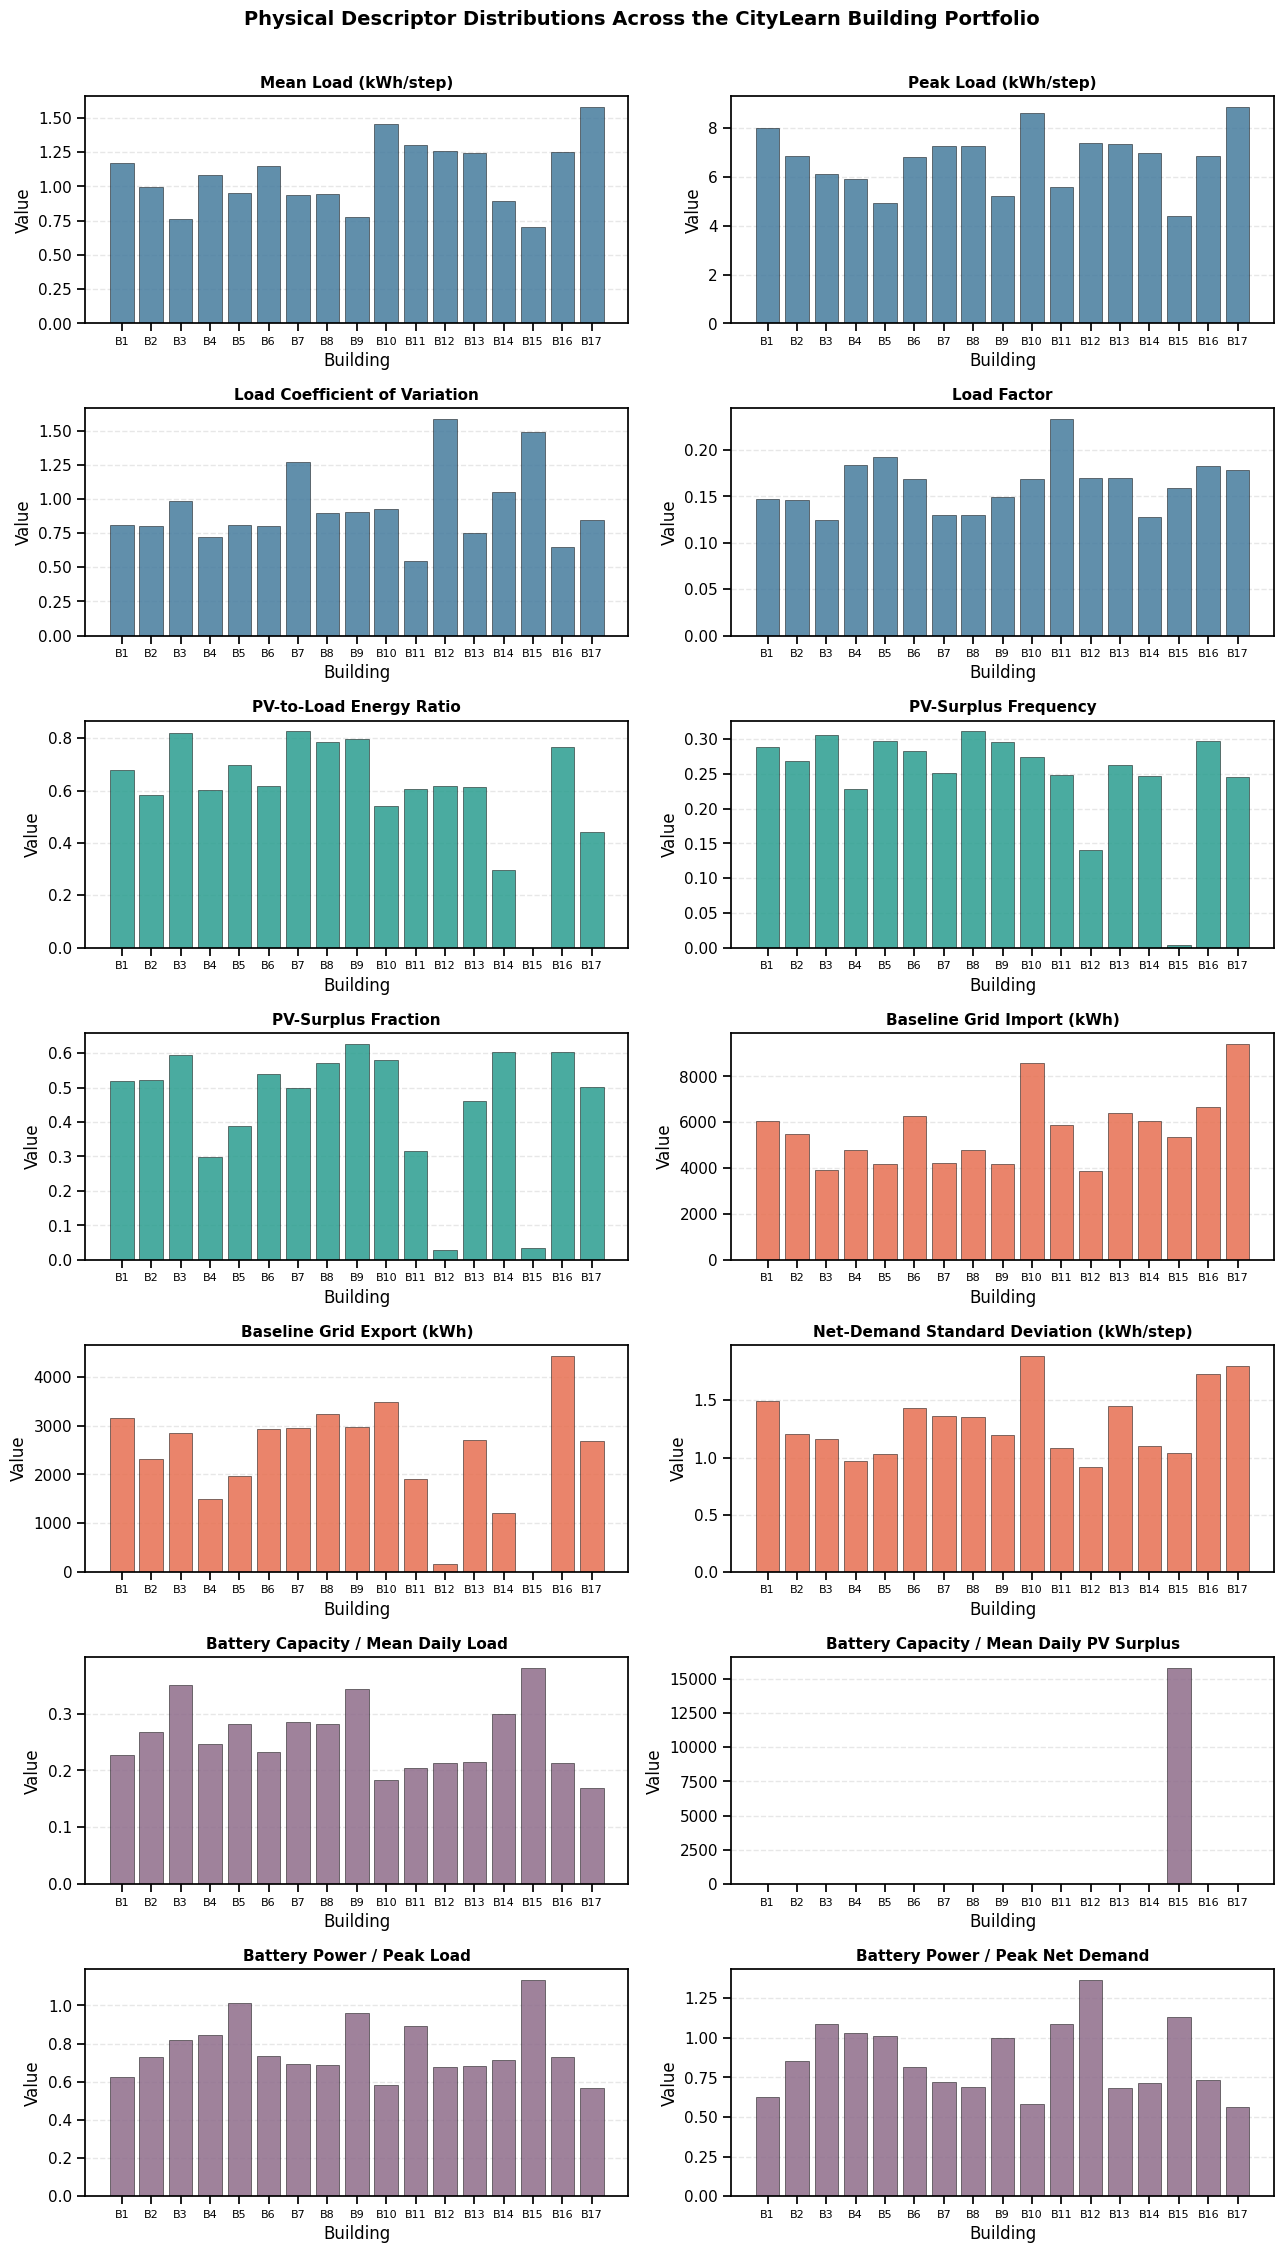

Displayed 14 physical descriptors for 17 buildings.


In [8]:
# --------------------------------------------------------------------------
# Visual audit of physical descriptor distributions across buildings
# --------------------------------------------------------------------------

# Descriptor names and publication-friendly axis labels.
descriptor_labels = {
    # Load descriptors
    'mean_load_kwh':
        'Mean Load (kWh/step)',

    'peak_load_kwh':
        'Peak Load (kWh/step)',

    'load_cv':
        'Load Coefficient of Variation',

    'load_factor':
        'Load Factor',

    # PV descriptors
    'pv_to_load_ratio':
        'PV-to-Load Energy Ratio',

    'pv_surplus_frequency':
        'PV-Surplus Frequency',

    'pv_surplus_fraction':
        'PV-Surplus Fraction',

    # Pre-storage grid-exchange descriptors
    'baseline_import_kwh':
        'Baseline Grid Import (kWh)',

    'baseline_export_kwh':
        'Baseline Grid Export (kWh)',

    'net_demand_std_kwh':
        'Net-Demand Standard Deviation (kWh/step)',

    # Optional battery-relative descriptors
    'battery_capacity_to_daily_load':
        'Battery Capacity / Mean Daily Load',

    'battery_capacity_to_pv_surplus':
        'Battery Capacity / Mean Daily PV Surplus',

    'battery_power_to_peak_load':
        'Battery Power / Peak Load',

    'battery_power_to_peak_net_demand':
        'Battery Power / Peak Net Demand'
}


# Desired descriptor order for visual inspection.
requested_audit_columns = [
    'mean_load_kwh',
    'peak_load_kwh',
    'load_cv',
    'load_factor',
    'pv_to_load_ratio',
    'pv_surplus_frequency',
    'pv_surplus_fraction',
    'baseline_import_kwh',
    'baseline_export_kwh',
    'net_demand_std_kwh',
    'battery_capacity_to_daily_load',
    'battery_capacity_to_pv_surplus',
    'battery_power_to_peak_load',
    'battery_power_to_peak_net_demand'
]


# Retain only descriptors available in the current table.
audit_columns = [
    column
    for column in requested_audit_columns
    if column in descriptors.columns
]


if not audit_columns:
    raise ValueError(
        'None of the requested audit descriptors were found '
        'in the descriptor table.'
    )


# Validate the selected descriptor values.
audit_data = descriptors[
    audit_columns
].copy()


if audit_data.isna().any().any():
    raise ValueError(
        'The selected audit descriptors contain missing values.'
    )


if not np.all(
    np.isfinite(
        audit_data.to_numpy(dtype=float)
    )
):
    raise ValueError(
        'The selected audit descriptors contain '
        'NaN or infinite values.'
    )


# --------------------------------------------------------------------------
# Create subplot layout
# --------------------------------------------------------------------------

ncols = 2

nrows = int(
    np.ceil(
        len(audit_columns)
        / float(ncols)
    )
)


fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(13, 3.2 * nrows)
)


# Ensure consistent one-dimensional iteration over axes.
axes = np.asarray(
    axes
).reshape(-1)


building_labels = [
    'B{}'.format(building_id)
    for building_id in audit_data.index
]


# Use colors to distinguish descriptor categories.
category_colors = {
    'load': '#457b9d',
    'pv': '#2a9d8f',
    'grid': '#e76f51',
    'battery': '#8e6c8a'
}


def get_descriptor_color(column):
    """Return a consistent color according to descriptor category."""

    if column.startswith('battery_'):
        return category_colors['battery']

    if (
        column.startswith('pv_')
        or 'pv_surplus' in column
    ):
        return category_colors['pv']

    if (
        column.startswith('baseline_')
        or 'net_demand' in column
    ):
        return category_colors['grid']

    return category_colors['load']


# --------------------------------------------------------------------------
# Plot every available descriptor
# --------------------------------------------------------------------------

for ax, column in zip(
    axes,
    audit_columns
):
    values = audit_data[
        column
    ].to_numpy(dtype=float)

    color = get_descriptor_color(
        column
    )

    ax.bar(
        building_labels,
        values,
        color=color,
        edgecolor='black',
        linewidth=0.4,
        alpha=0.85
    )

    readable_label = descriptor_labels.get(
        column,
        column.replace('_', ' ').title()
    )

    ax.set_title(
        readable_label,
        fontsize=11,
        fontweight='bold'
    )

    ax.set_xlabel(
        'Building'
    )

    ax.set_ylabel(
        'Value'
    )

    ax.tick_params(
        axis='x',
        labelrotation=0,
        labelsize=8
    )

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.30
    )

    ax.set_axisbelow(
        True
    )


# Hide unused subplot positions.
for ax in axes[
    len(audit_columns):
]:
    ax.axis(
        'off'
    )


fig.suptitle(
    'Physical Descriptor Distributions Across '
    'the CityLearn Building Portfolio',
    fontsize=14,
    fontweight='bold',
    y=1.005
)


plt.tight_layout()
plt.show()


print(
    'Displayed {} physical descriptors for {} buildings.'.format(
        len(audit_columns),
        len(audit_data)
    )
)


missing_optional_columns = [
    column
    for column in requested_audit_columns
    if column not in descriptors.columns
]


if missing_optional_columns:
    print(
        '\nDescriptors not displayed because they are unavailable:'
    )

    for column in missing_optional_columns:
        print(
            '  -',
            column
        )

## 9. Select physically complementary clustering features

Review the redundancy table before modifying this list. Do not include several near-duplicate measures of the same scale effect.


In [9]:
# --------------------------------------------------------------------------
# Select physically complementary descriptors for clustering
# --------------------------------------------------------------------------

# Core descriptors are selected to represent different dimensions of the
# PV-battery control problem while limiting redundant feature weighting.
SELECTED_FEATURES = [
    # Building-demand scale
    'peak_load_kwh',

    # Relative load variability
    'load_cv',

    # PV penetration relative to demand
    'pv_to_load_ratio',

    # Frequency of time steps with PV surplus
    'pv_surplus_frequency',

    # Fraction of PV generation exported without storage
    'pv_surplus_fraction',

    # Absolute variability of pre-storage net demand
    'net_demand_std_kwh',

    # Maximum import requirement without storage
    'peak_positive_net_demand_kwh',
]


# Add battery-relative descriptors when battery metadata are available.
optional_battery_features = [
    'battery_capacity_to_daily_load',
    'battery_power_to_peak_net_demand',
]

for feature in optional_battery_features:
    if feature in descriptors.columns:
        SELECTED_FEATURES.append(feature)


# --------------------------------------------------------------------------
# Validate selected features
# --------------------------------------------------------------------------

missing_features = [
    feature
    for feature in SELECTED_FEATURES
    if feature not in descriptors.columns
]

if missing_features:
    raise KeyError(
        'The following selected clustering features are missing: {}'.format(
            missing_features
        )
    )


constant_selected_features = [
    feature
    for feature in SELECTED_FEATURES
    if descriptors[feature].nunique(
        dropna=False
    ) <= 1
]

if constant_selected_features:
    raise ValueError(
        'The following selected features are constant across all buildings '
        'and provide no clustering information: {}'.format(
            constant_selected_features
        )
    )


selected_data = descriptors[
    SELECTED_FEATURES
].copy()

if selected_data.isna().any().any():
    raise ValueError(
        'The selected clustering features contain missing values.'
    )

if not np.all(
    np.isfinite(
        selected_data.to_numpy(dtype=float)
    )
):
    raise ValueError(
        'The selected clustering features contain NaN or '
        'infinite values.'
    )


# --------------------------------------------------------------------------
# Audit correlation among the selected descriptors
# --------------------------------------------------------------------------

selected_feature_correlation = selected_data.corr(
    method='spearman'
)

high_correlation_pairs = []

for left_index, left_feature in enumerate(
    SELECTED_FEATURES
):
    for right_feature in SELECTED_FEATURES[
        left_index + 1:
    ]:
        correlation = selected_feature_correlation.loc[
            left_feature,
            right_feature
        ]

        if abs(correlation) >= REDUNDANCY_THRESHOLD:
            high_correlation_pairs.append({
                'feature_1': left_feature,
                'feature_2': right_feature,
                'spearman_correlation': correlation
            })


print('Final clustering features:')

for feature_number, feature in enumerate(
    SELECTED_FEATURES,
    start=1
):
    print(
        '  {}. {}'.format(
            feature_number,
            feature
        )
    )


print(
    '\nNumber of selected features:',
    len(SELECTED_FEATURES)
)


if high_correlation_pairs:
    print(
        '\nWarning: the following selected feature pairs exceed '
        'the redundancy threshold of {:.2f}:'.format(
            REDUNDANCY_THRESHOLD
        )
    )

    high_correlation_table = pd.DataFrame(
        high_correlation_pairs
    )

    display(
        high_correlation_table.sort_values(
            'spearman_correlation',
            key=np.abs,
            ascending=False
        ).round(4)
    )

    print(
        'Review these pairs before final clustering. Retain both only '
        'when they represent distinct physical aspects of the '
        'battery-control problem.'
    )

else:
    print(
        '\nNo selected feature pair exceeds the redundancy threshold '
        'of {:.2f}.'.format(
            REDUNDANCY_THRESHOLD
        )
    )

Final clustering features:
  1. peak_load_kwh
  2. load_cv
  3. pv_to_load_ratio
  4. pv_surplus_frequency
  5. pv_surplus_fraction
  6. net_demand_std_kwh
  7. peak_positive_net_demand_kwh
  8. battery_capacity_to_daily_load
  9. battery_power_to_peak_net_demand

Number of selected features: 9



,feature_1,feature_2,spearman_correlation
0,peak_positive_net_demand_kwh,battery_power_to_peak_net_demand,-1.0


Review these pairs before final clustering. Retain both only when they represent distinct physical aspects of the battery-control problem.


## 10. Robust scaling


In [10]:
# --------------------------------------------------------------------------
# Robustly scale the selected physical descriptors
# --------------------------------------------------------------------------

# Preserve the building order explicitly.
building_index = descriptors.index.copy()

# Extract the selected descriptor matrix.
X_physical = descriptors[
    SELECTED_FEATURES
].to_numpy(dtype=float)


# --------------------------------------------------------------------------
# Validate the unscaled matrix
# --------------------------------------------------------------------------

if X_physical.shape[0] != len(BUILDING_IDS):
    raise ValueError(
        'Expected {} buildings, but the physical descriptor matrix '
        'contains {} rows.'.format(
            len(BUILDING_IDS),
            X_physical.shape[0]
        )
    )

if X_physical.shape[1] != len(SELECTED_FEATURES):
    raise ValueError(
        'Expected {} selected features, but the physical descriptor '
        'matrix contains {} columns.'.format(
            len(SELECTED_FEATURES),
            X_physical.shape[1]
        )
    )

if not np.all(np.isfinite(X_physical)):
    raise ValueError(
        'The unscaled physical descriptor matrix contains '
        'NaN or infinite values.'
    )


# --------------------------------------------------------------------------
# Apply robust scaling
# --------------------------------------------------------------------------

# RobustScaler centers each descriptor using its median and scales it
# using the interquartile range. This reduces the influence of extreme
# buildings while keeping all selected descriptors on comparable scales.
scaler = RobustScaler(
    with_centering=True,
    with_scaling=True,
    quantile_range=(25.0, 75.0)
)

X_scaled = scaler.fit_transform(
    X_physical
)


# --------------------------------------------------------------------------
# Validate the scaled matrix
# --------------------------------------------------------------------------

if X_scaled.shape != X_physical.shape:
    raise ValueError(
        'The scaled descriptor matrix has an unexpected shape: '
        '{} instead of {}.'.format(
            X_scaled.shape,
            X_physical.shape
        )
    )

if not np.all(np.isfinite(X_scaled)):
    raise ValueError(
        'The scaled descriptor matrix contains '
        'NaN or infinite values.'
    )


# --------------------------------------------------------------------------
# Create interpretable scaled-descriptor tables
# --------------------------------------------------------------------------

scaled_descriptors = pd.DataFrame(
    X_scaled,
    index=building_index,
    columns=SELECTED_FEATURES
)

scaled_descriptors.index.name = 'building_id'


# Save the fitted scaling parameters for reproducibility.
scaling_parameters = pd.DataFrame({
    'feature': SELECTED_FEATURES,
    'median_center': scaler.center_,
    'interquartile_range': scaler.scale_
}).set_index('feature')


print(
    'Scaled descriptor matrix shape:',
    scaled_descriptors.shape
)

print(
    '\nRobustly scaled physical descriptors:'
)

display(
    scaled_descriptors.round(3)
)


print(
    '\nRobust-scaling parameters:'
)

display(
    scaling_parameters.round(4)
)


# --------------------------------------------------------------------------
# Save scaled data and scaling parameters
# --------------------------------------------------------------------------

scaled_descriptors.to_csv(
    OUTPUT_DIR
    / 'building_scaled_descriptors.csv'
)

scaling_parameters.to_csv(
    OUTPUT_DIR
    / 'robust_scaling_parameters.csv'
)

print(
    '\nScaled descriptors and scaling parameters saved to:',
    OUTPUT_DIR.resolve()
)

Scaled descriptor matrix shape: (17, 9)

Robustly scaled physical descriptors:


,peak_load_kwh,load_cv,pv_to_load_ratio,pv_surplus_frequency,pv_surplus_fraction,net_demand_std_kwh,peak_positive_net_demand_kwh,battery_capacity_to_daily_load,battery_power_to_peak_net_demand
building_id,,,,,,,,,
1,0.794,-0.206,0.338,0.399,0.000,0.786,0.765,-0.268,-0.552
2,0.000,-0.244,-0.175,0.000,0.010,0.000,-0.120,0.302,0.119
3,-0.514,0.756,1.101,0.769,0.401,-0.127,-0.636,1.471,0.794
4,-0.650,-0.681,-0.068,-0.845,-1.147,-0.638,-0.530,0.000,0.628
5,-1.321,-0.184,0.448,0.584,-0.686,-0.466,-0.498,0.489,0.580
6,-0.036,-0.237,0.014,0.282,0.100,0.612,0.000,-0.194,0.000
7,0.275,2.309,1.137,-0.373,-0.109,0.415,0.319,0.535,-0.266
8,0.295,0.261,0.913,0.863,0.270,0.394,0.470,0.507,-0.372
9,-1.145,0.310,0.971,0.539,0.569,-0.024,-0.477,1.368,0.550



Robust-scaling parameters:


,median_center,interquartile_range
feature,,
peak_load_kwh,6.8431,1.4419
load_cv,0.8458,0.1839
pv_to_load_ratio,0.6158,0.1846
pv_surplus_frequency,0.2690,0.0486
pv_surplus_fraction,0.5188,0.1911
net_demand_std_kwh,1.2057,0.3697
peak_positive_net_demand_kwh,6.1378,2.4077
battery_capacity_to_daily_load,0.2463,0.0712
battery_power_to_peak_net_demand,0.8146,0.3408



Scaled descriptors and scaling parameters saved to: C:\Users\Umair\Desktop\Ongoing_research\Summer\New folder\building_clustering_outputs


## 11. Screen the number of K-means clusters

Use all indices together with cluster sizes, physical interpretation, and stability. Do not select `K` from one index alone.


K-means cluster-number evaluation:


,n_clusters,silhouette,calinski_harabasz,davies_bouldin,inertia,minimum_cluster_size,maximum_cluster_size,cluster_size_imbalance,iterations_to_convergence,reached_iteration_limit
0,2,0.5677,15.1858,0.6944,78.4694,2,15,7.5,2,False
1,3,0.2352,12.1446,1.0964,57.7384,2,9,4.5,5,False
2,4,0.2087,11.6364,0.7757,42.8487,1,9,9.0,3,False
3,5,0.2342,12.0385,0.7283,31.5013,1,8,8.0,2,False


Best K by silhouette score: 2
Best K by Calinski-Harabasz score: 2
Best K by Davies-Bouldin score: 2

These metric-specific values are diagnostics only. The final K must also consider cluster size, temporal stability, algorithm agreement, and physical interpretation.


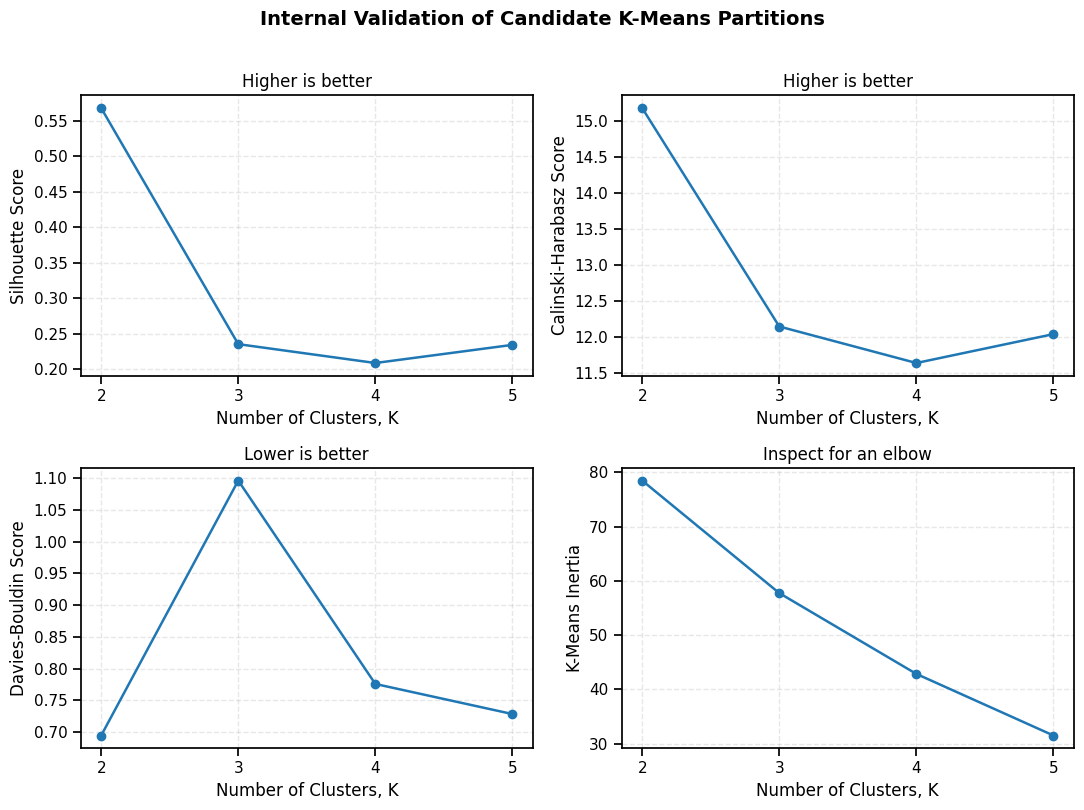

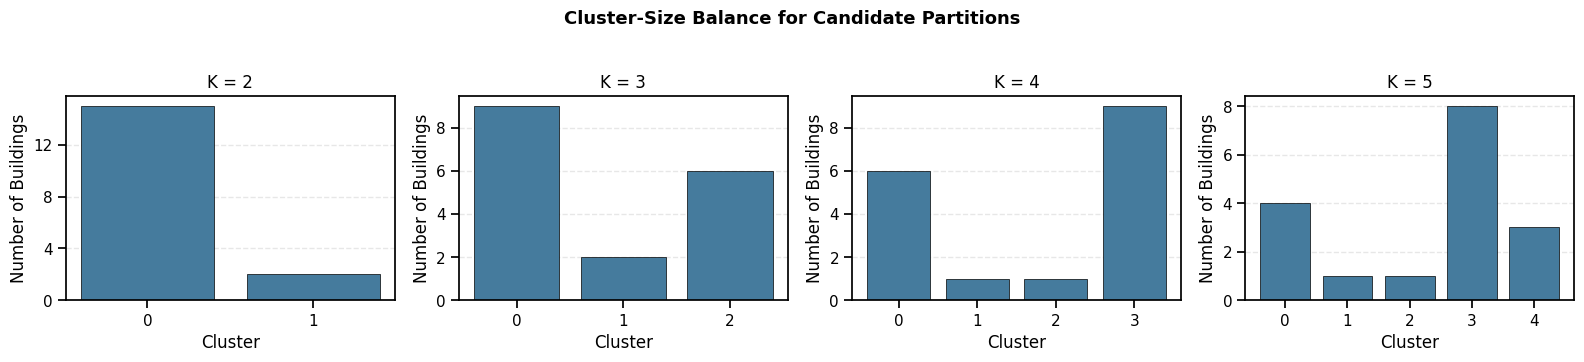


Cluster-quality results saved to: C:\Users\Umair\Desktop\Ongoing_research\Summer\New folder\building_clustering_outputs\cluster_number_quality.csv


In [11]:
# --------------------------------------------------------------------------
# Evaluate candidate numbers of K-means clusters
# --------------------------------------------------------------------------

# Validate the scaled descriptor matrix.
if X_scaled.ndim != 2:
    raise ValueError(
        'X_scaled must be a two-dimensional matrix. '
        'Received shape: {}'.format(X_scaled.shape)
    )

n_buildings, n_features = X_scaled.shape

if n_buildings != len(BUILDING_IDS):
    raise ValueError(
        'X_scaled contains {} building rows, but {} buildings '
        'were expected.'.format(
            n_buildings,
            len(BUILDING_IDS)
        )
    )

if n_features != len(SELECTED_FEATURES):
    raise ValueError(
        'X_scaled contains {} features, but {} selected features '
        'were expected.'.format(
            n_features,
            len(SELECTED_FEATURES)
        )
    )

if not np.all(np.isfinite(X_scaled)):
    raise ValueError(
        'X_scaled contains NaN or infinite values.'
    )


# --------------------------------------------------------------------------
# Validate candidate cluster counts
# --------------------------------------------------------------------------

valid_k_values = sorted({
    int(k)
    for k in K_VALUES
    if 2 <= int(k) < n_buildings
})

if not valid_k_values:
    raise ValueError(
        'K_VALUES must contain at least one integer satisfying '
        '2 <= K < number of buildings.'
    )

excluded_k_values = [
    k
    for k in K_VALUES
    if int(k) not in valid_k_values
]

if excluded_k_values:
    print(
        'Excluded invalid K values:',
        excluded_k_values
    )


# --------------------------------------------------------------------------
# Fit K-means and calculate internal validation indices
# --------------------------------------------------------------------------

quality_records = []
cluster_models = {}
cluster_labels_by_k = {}

for n_clusters in valid_k_values:

    model = KMeans(
    n_clusters=n_clusters,
    random_state=RANDOM_STATE,
    n_init=KMEANS_N_INIT,
    max_iter=KMEANS_MAX_ITER,
    algorithm='full')

    labels_k = model.fit_predict(
        X_scaled
    )

    observed_clusters = np.unique(
        labels_k
    )

    if len(observed_clusters) != n_clusters:
        raise RuntimeError(
            'K-means requested {} clusters but produced {} '
            'nonempty clusters.'.format(
                n_clusters,
                len(observed_clusters)
            )
        )

    cluster_sizes = np.bincount(
        labels_k,
        minlength=n_clusters
    )

    silhouette = silhouette_score(
        X_scaled,
        labels_k,
        metric='euclidean'
    )

    calinski_harabasz = calinski_harabasz_score(
        X_scaled,
        labels_k
    )

    davies_bouldin = davies_bouldin_score(
        X_scaled,
        labels_k
    )

    quality_records.append({
        'n_clusters':
            n_clusters,

        'silhouette':
            float(silhouette),

        'calinski_harabasz':
            float(calinski_harabasz),

        'davies_bouldin':
            float(davies_bouldin),

        'inertia':
            float(model.inertia_),

        'minimum_cluster_size':
            int(cluster_sizes.min()),

        'maximum_cluster_size':
            int(cluster_sizes.max()),

        'cluster_size_imbalance':
            float(
                cluster_sizes.max()
                / cluster_sizes.min()
            ),

        'iterations_to_convergence':
            int(model.n_iter_),

        'reached_iteration_limit':
            bool(
                model.n_iter_
                >= KMEANS_MAX_ITER
            )
    })

    cluster_models[n_clusters] = model

    cluster_labels_by_k[n_clusters] = (
        labels_k.copy()
    )


# --------------------------------------------------------------------------
# Create and validate the quality table
# --------------------------------------------------------------------------

cluster_quality = (
    pd.DataFrame(quality_records)
    .sort_values('n_clusters')
    .reset_index(drop=True)
)

quality_metric_columns = [
    'silhouette',
    'calinski_harabasz',
    'davies_bouldin',
    'inertia'
]

if not np.all(
    np.isfinite(
        cluster_quality[
            quality_metric_columns
        ].to_numpy(dtype=float)
    )
):
    raise ValueError(
        'The cluster-quality table contains '
        'NaN or infinite metric values.'
    )


print(
    'K-means cluster-number evaluation:'
)

display(
    cluster_quality.round(4)
)


# --------------------------------------------------------------------------
# Identify metric-specific candidates
# --------------------------------------------------------------------------

best_silhouette_k = int(
    cluster_quality.loc[
        cluster_quality[
            'silhouette'
        ].idxmax(),
        'n_clusters'
    ]
)

best_calinski_k = int(
    cluster_quality.loc[
        cluster_quality[
            'calinski_harabasz'
        ].idxmax(),
        'n_clusters'
    ]
)

best_davies_k = int(
    cluster_quality.loc[
        cluster_quality[
            'davies_bouldin'
        ].idxmin(),
        'n_clusters'
    ]
)


print(
    'Best K by silhouette score:',
    best_silhouette_k
)

print(
    'Best K by Calinski-Harabasz score:',
    best_calinski_k
)

print(
    'Best K by Davies-Bouldin score:',
    best_davies_k
)

print(
    '\nThese metric-specific values are diagnostics only. '
    'The final K must also consider cluster size, temporal '
    'stability, algorithm agreement, and physical interpretation.'
)


# --------------------------------------------------------------------------
# Plot cluster-number diagnostics
# --------------------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(11, 8)
)

plot_definitions = [
    (
        'silhouette',
        'Silhouette Score',
        'Higher is better'
    ),
    (
        'calinski_harabasz',
        'Calinski-Harabasz Score',
        'Higher is better'
    ),
    (
        'davies_bouldin',
        'Davies-Bouldin Score',
        'Lower is better'
    ),
    (
        'inertia',
        'K-Means Inertia',
        'Inspect for an elbow'
    )
]


for ax, (
    metric,
    y_label,
    interpretation
) in zip(
    axes.reshape(-1),
    plot_definitions
):
    ax.plot(
        cluster_quality['n_clusters'],
        cluster_quality[metric],
        marker='o',
        linewidth=1.8,
        markersize=6
    )

    ax.set_xlabel(
        'Number of Clusters, K'
    )

    ax.set_ylabel(
        y_label
    )

    ax.set_title(
        interpretation
    )

    ax.xaxis.set_major_locator(
        ticker.MaxNLocator(
            nbins=len(valid_k_values),
            integer=True
        )
    )

    ax.grid(
        linestyle='--',
        alpha=0.30
    )

    ax.set_axisbelow(
        True
    )


fig.suptitle(
    'Internal Validation of Candidate K-Means Partitions',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.show()


# --------------------------------------------------------------------------
# Plot cluster-size balance for each candidate K
# --------------------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(valid_k_values),
    figsize=(4.0 * len(valid_k_values), 3.5),
    squeeze=False
)

for plot_index, n_clusters in enumerate(
    valid_k_values
):
    ax = axes[0, plot_index]

    labels_k = cluster_labels_by_k[
        n_clusters
    ]

    cluster_sizes = np.bincount(
        labels_k,
        minlength=n_clusters
    )

    ax.bar(
        np.arange(n_clusters),
        cluster_sizes,
        color='#457b9d',
        edgecolor='black',
        linewidth=0.5
    )

    ax.set_title(
        'K = {}'.format(n_clusters)
    )

    ax.set_xlabel(
        'Cluster'
    )

    ax.set_ylabel(
        'Number of Buildings'
    )

    ax.set_xticks(
        np.arange(n_clusters)
    )

    ax.yaxis.set_major_locator(
        ticker.MaxNLocator(
            nbins=5,
            integer=True
        )
    )

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.30
    )

    ax.set_axisbelow(
        True
    )


fig.suptitle(
    'Cluster-Size Balance for Candidate Partitions',
    fontsize=13,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()
plt.show()


# --------------------------------------------------------------------------
# Save cluster-number diagnostics
# --------------------------------------------------------------------------

quality_output_path = (
    OUTPUT_DIR
    / 'cluster_number_quality.csv'
)

cluster_quality.to_csv(
    quality_output_path,
    index=False
)

print(
    '\nCluster-quality results saved to:',
    quality_output_path.resolve()
)

## 12. Select final K and inspect physical cluster summaries

`FINAL_K = 3` is a development-panel target, not an automatic statistical truth. Change it if diagnostics and physical interpretation support another value.


In [12]:
# --------------------------------------------------------------------------
# Select the final K-means partition and summarize the clusters
# --------------------------------------------------------------------------

FINAL_K = 3


# --------------------------------------------------------------------------
# Validate the selected cluster count
# --------------------------------------------------------------------------

if FINAL_K not in cluster_models:
    raise ValueError(
        'FINAL_K={} was not screened. Available K values: {}'.format(
            FINAL_K,
            sorted(cluster_models.keys())
        )
    )

if FINAL_K not in cluster_labels_by_k:
    raise KeyError(
        'Cluster labels are unavailable for FINAL_K={}.'.format(
            FINAL_K
        )
    )


# --------------------------------------------------------------------------
# Retrieve the fitted K-means model and labels
# --------------------------------------------------------------------------

kmeans_model = cluster_models[FINAL_K]

cluster_labels = np.asarray(
    cluster_labels_by_k[FINAL_K],
    dtype=int
).copy()


if len(cluster_labels) != len(BUILDING_IDS):
    raise ValueError(
        'Expected {} cluster labels, but found {}.'.format(
            len(BUILDING_IDS),
            len(cluster_labels)
        )
    )


unique_clusters = np.unique(
    cluster_labels
)


if len(unique_clusters) != FINAL_K:
    raise ValueError(
        'Expected {} nonempty clusters, but found {}: {}'.format(
            FINAL_K,
            len(unique_clusters),
            unique_clusters.tolist()
        )
    )


if kmeans_model.n_iter_ >= KMEANS_MAX_ITER:
    print(
        'WARNING: K-means reached the maximum iteration limit.'
    )
else:
    print(
        'K-means converged in {} iterations.'.format(
            kmeans_model.n_iter_
        )
    )


# --------------------------------------------------------------------------
# Create the building-to-cluster assignment table
# --------------------------------------------------------------------------

cluster_assignments = pd.DataFrame({
    'building_id': BUILDING_IDS,
    'cluster': cluster_labels
}).set_index(
    'building_id'
).sort_index()


if cluster_assignments.index.duplicated().any():
    raise ValueError(
        'The cluster-assignment table contains duplicated building IDs.'
    )


if not cluster_assignments.index.equals(
    descriptors.index
):
    raise ValueError(
        'Building order in cluster assignments does not match '
        'the descriptor-table order.'
    )


# Join cluster labels with descriptors in physical units.
clustered_descriptors = descriptors.join(
    cluster_assignments,
    how='inner'
)


# Join cluster labels with robustly scaled descriptors.
clustered_scaled_descriptors = scaled_descriptors.join(
    cluster_assignments,
    how='inner'
)


if clustered_descriptors.shape[0] != len(BUILDING_IDS):
    raise ValueError(
        'Unexpected number of rows after joining descriptors '
        'and cluster assignments.'
    )


# --------------------------------------------------------------------------
# Report cluster sizes and members
# --------------------------------------------------------------------------

cluster_sizes = (
    cluster_assignments['cluster']
    .value_counts()
    .sort_index()
)


print('\nSelected number of clusters:', FINAL_K)

print(
    'K-means inertia: {:.6f}'.format(
        kmeans_model.inertia_
    )
)

print('\nCluster sizes:')

display(
    cluster_sizes.rename(
        'number_of_buildings'
    ).to_frame()
)


cluster_member_records = []

print('Cluster members:')

for cluster_id in sorted(unique_clusters):
    members = (
        cluster_assignments[
            cluster_assignments['cluster'] == cluster_id
        ]
        .index
        .astype(int)
        .tolist()
    )

    print(
        '  Cluster {}: {}'.format(
            cluster_id,
            members
        )
    )

    for building_id in members:
        cluster_member_records.append({
            'cluster': int(cluster_id),
            'building_id': int(building_id)
        })


cluster_members_table = pd.DataFrame(
    cluster_member_records
)


# --------------------------------------------------------------------------
# Summarize descriptors in their original physical units
# --------------------------------------------------------------------------

cluster_physical_medians = (
    clustered_descriptors
    .groupby('cluster')[SELECTED_FEATURES]
    .median()
)

cluster_physical_means = (
    clustered_descriptors
    .groupby('cluster')[SELECTED_FEATURES]
    .mean()
)

cluster_physical_std = (
    clustered_descriptors
    .groupby('cluster')[SELECTED_FEATURES]
    .std(ddof=0)
)


print('\nMedian physical descriptors by cluster:')

display(
    cluster_physical_medians.round(4)
)


print('Mean physical descriptors by cluster:')

display(
    cluster_physical_means.round(4)
)


print('Within-cluster descriptor standard deviations:')

display(
    cluster_physical_std.round(4)
)


# --------------------------------------------------------------------------
# Summarize descriptors in the robustly scaled clustering space
# --------------------------------------------------------------------------

cluster_scaled_medians = (
    clustered_scaled_descriptors
    .groupby('cluster')[SELECTED_FEATURES]
    .median()
)

cluster_scaled_means = (
    clustered_scaled_descriptors
    .groupby('cluster')[SELECTED_FEATURES]
    .mean()
)


print('Median robustly scaled descriptors by cluster:')

display(
    cluster_scaled_medians.round(3)
)


print('Mean robustly scaled descriptors by cluster:')

display(
    cluster_scaled_means.round(3)
)


# --------------------------------------------------------------------------
# Create a compact cluster-membership summary
# --------------------------------------------------------------------------

cluster_profile_records = []

for cluster_id in sorted(unique_clusters):
    members = (
        cluster_members_table[
            cluster_members_table['cluster'] == cluster_id
        ]['building_id']
        .astype(int)
        .tolist()
    )

    cluster_profile_records.append({
        'cluster': int(cluster_id),
        'number_of_buildings': len(members),
        'members': ', '.join(
            'B{}'.format(building_id)
            for building_id in members
        )
    })


cluster_profile_table = (
    pd.DataFrame(cluster_profile_records)
    .set_index('cluster')
)


print('Compact cluster profile:')

display(
    cluster_profile_table
)


# --------------------------------------------------------------------------
# Safely save assignments and cluster summaries
# --------------------------------------------------------------------------

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


output_tables = {
    'building_cluster_assignments.csv':
        cluster_assignments.reset_index(),

    'cluster_members.csv':
        cluster_members_table,

    'cluster_physical_medians.csv':
        cluster_physical_medians.reset_index(),

    'cluster_physical_means.csv':
        cluster_physical_means.reset_index(),

    'cluster_physical_standard_deviations.csv':
        cluster_physical_std.reset_index(),

    'cluster_scaled_medians.csv':
        cluster_scaled_medians.reset_index(),

    'cluster_scaled_means.csv':
        cluster_scaled_means.reset_index(),

    'cluster_profile.csv':
        cluster_profile_table.reset_index()
}


for filename, output_table in output_tables.items():
    output_path = OUTPUT_DIR / filename

    try:
        output_table.to_csv(
            output_path,
            index=False
        )

    except PermissionError:
        alternative_path = (
            OUTPUT_DIR
            / filename.replace(
                '.csv',
                '_new.csv'
            )
        )

        output_table.to_csv(
            alternative_path,
            index=False
        )

        print(
            'WARNING: {} could not be overwritten, probably '
            'because it is open in Excel. Saved as {}.'.format(
                filename,
                alternative_path.name
            )
        )


print(
    '\nCluster assignments and summaries saved to:'
)

print(
    OUTPUT_DIR.resolve()
)

K-means converged in 5 iterations.

Selected number of clusters: 3
K-means inertia: 57.738422

Cluster sizes:


,number_of_buildings
0,9
1,2
2,6


Cluster members:
  Cluster 0: [1, 6, 7, 8, 10, 13, 14, 16, 17]
  Cluster 1: [12, 15]
  Cluster 2: [2, 3, 4, 5, 9, 11]

Median physical descriptors by cluster:


,peak_load_kwh,load_cv,pv_to_load_ratio,pv_surplus_frequency,pv_surplus_fraction,net_demand_std_kwh,peak_positive_net_demand_kwh,battery_capacity_to_daily_load,battery_power_to_peak_net_demand
cluster,,,,,,,,,
0,7.2682,0.8458,0.6183,0.2736,0.5379,1.4512,7.2682,0.2272,0.6879
1,5.9023,1.5357,0.3082,0.0718,0.0317,0.9809,4.0366,0.2965,1.2494
2,5.7471,0.8064,0.6515,0.2821,0.4542,1.1200,4.8996,0.2745,1.0206


Mean physical descriptors by cluster:


...

Mean robustly scaled descriptors by cluster:


,peak_load_kwh,load_cv,pv_to_load_ratio,pv_surplus_frequency,pv_surplus_fraction,net_demand_std_kwh,peak_positive_net_demand_kwh,battery_capacity_to_daily_load,battery_power_to_peak_net_demand
cluster,,,,,,,,,
0,0.487,0.235,0.015,0.084,0.117,0.828,0.538,-0.173,-0.393
1,-0.652,3.752,-1.666,-4.056,-2.549,-0.608,-0.873,0.705,1.276
2,-0.750,-0.277,0.369,0.104,-0.318,-0.265,-0.484,0.508,0.580


Compact cluster profile:


,number_of_buildings,members
cluster,,
0,9,"B1, B6, B7, B8, B10, B13, B14, B16, B17"
1,2,"B12, B15"
2,6,"B2, B3, B4, B5, B9, B11"



Cluster assignments and summaries saved to:
C:\Users\Umair\Desktop\Ongoing_research\Summer\New folder\building_clustering_outputs


## 13. Initialization stability

ARI is label-invariant. Low ARI indicates that the selected partition depends strongly on initialization.


In [13]:
repeat_labels = []
repeat_inertias = []
for seed in range(N_INITIALIZATION_REPEATS):
    model = KMeans(n_clusters=FINAL_K, random_state=seed,
                   n_init=KMEANS_N_INIT, max_iter=KMEANS_MAX_ITER)
    repeat_labels.append(model.fit_predict(X_scaled))
    repeat_inertias.append(model.inertia_)

ari_values = []
for i in range(len(repeat_labels)):
    for j in range(i+1, len(repeat_labels)):
        ari_values.append(adjusted_rand_score(repeat_labels[i], repeat_labels[j]))

initialization_stability = {
    'mean_pairwise_ari': float(np.mean(ari_values)),
    'minimum_pairwise_ari': float(np.min(ari_values)),
    'maximum_pairwise_ari': float(np.max(ari_values)),
    'inertia_mean': float(np.mean(repeat_inertias)),
    'inertia_std': float(np.std(repeat_inertias, ddof=1)),
}
print(json.dumps(initialization_stability, indent=2))


{
  "mean_pairwise_ari": 0.9352965446106241,
  "minimum_pairwise_ari": 0.7851985559566786,
  "maximum_pairwise_ari": 1.0,
  "inertia_mean": 57.77252305068067,
  "inertia_std": 0.07352310453678458
}


## 14. Day-bootstrap stability

Complete days are resampled with replacement, descriptors are recomputed, and the resulting clustering is compared with the reference partition.


K-means initialization-stability summary:
{
  "final_k": 3,
  "number_of_repeats": 50,
  "number_of_pairwise_comparisons": 1225,
  "mean_pairwise_ari": 0.9352965446106241,
  "median_pairwise_ari": 1.0,
  "minimum_pairwise_ari": 0.7851985559566786,
  "maximum_pairwise_ari": 1.0,
  "pairwise_ari_std": 0.09858901073565177,
  "mean_ari_vs_reference": 0.9613357400722022,
  "minimum_ari_vs_reference": 0.7851985559566786,
  "inertia_mean": 57.77252305068067,
  "inertia_std": 0.07352310453678458,
  "inertia_minimum": 57.73842212241048,
  "inertia_maximum": 57.927871723911494,
  "mean_iterations_to_convergence": 2.78,
  "maximum_iterations_to_convergence": 5,
  "number_reaching_iteration_limit": 0
}

Results from individual random-state repetitions:


,random_state,adjusted_rand_index_vs_reference,inertia,iterations_to_convergence,reached_iteration_limit
0,0,1.000000,57.738422,5,False
1,1,1.000000,57.738422,3,False
2,2,1.000000,57.738422,3,False
3,3,1.000000,57.738422,3,False
4,4,1.000000,57.738422,3,False
5,5,1.000000,57.738422,3,False
6,6,1.000000,57.738422,3,False
7,7,1.000000,57.738422,3,False
8,8,1.000000,57.738422,2,False
9,9,1.000000,57.738422,3,False


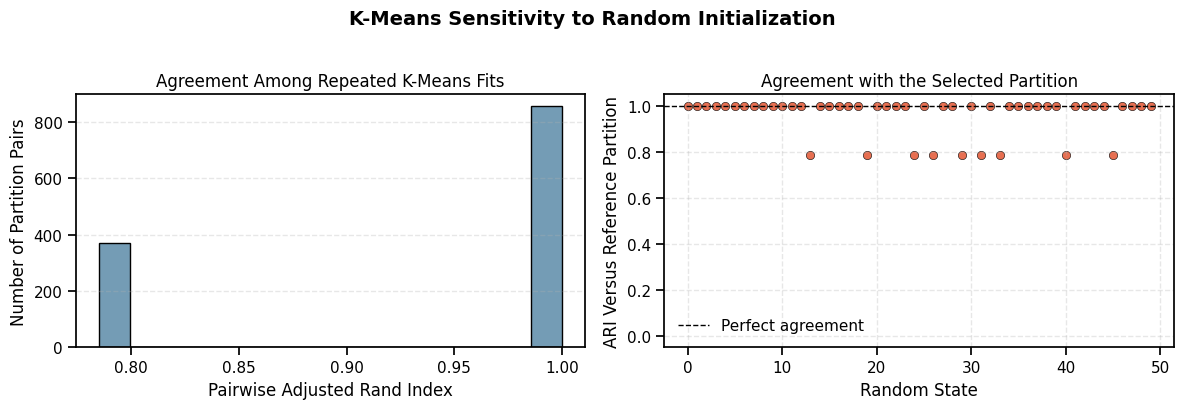


Initialization-stability outputs saved to:
C:\Users\Umair\Desktop\Ongoing_research\Summer\New folder\building_clustering_outputs


In [14]:
# --------------------------------------------------------------------------
# Evaluate K-means stability across random initializations
# --------------------------------------------------------------------------

if FINAL_K not in cluster_models:
    raise ValueError(
        'FINAL_K={} was not previously evaluated.'.format(
            FINAL_K
        )
    )
if len(cluster_labels) != X_scaled.shape[0]:
    raise ValueError(
        'Reference cluster labels and X_scaled contain '
        'different numbers of buildings.'
    )

if N_INITIALIZATION_REPEATS < 2:
    raise ValueError(
        'N_INITIALIZATION_REPEATS must be at least 2.'
    )

if not np.all(np.isfinite(X_scaled)):
    raise ValueError(
        'X_scaled contains NaN or infinite values.'
    )


# --------------------------------------------------------------------------
# Repeat the complete K-means fitting procedure
# --------------------------------------------------------------------------

repeat_labels = []
repeat_inertias = []
repeat_iterations = []
repeat_reference_ari = []
repeat_records = []

for repeat_seed in range(
    N_INITIALIZATION_REPEATS
):
    repeated_model = KMeans(
        n_clusters=FINAL_K,
        random_state=repeat_seed,
        n_init=KMEANS_N_INIT,
        max_iter=KMEANS_MAX_ITER,

        # Compatible with scikit-learn 1.0.2.
        algorithm='full'
    )

    repeated_labels = repeated_model.fit_predict(
        X_scaled
    )

    unique_repeated_clusters = np.unique(
        repeated_labels
    )

    if len(unique_repeated_clusters) != FINAL_K:
        raise RuntimeError(
            'Repeated K-means fit with random_state={} '
            'produced {} nonempty clusters instead of {}.'.format(
                repeat_seed,
                len(unique_repeated_clusters),
                FINAL_K
            )
        )

    reference_ari = adjusted_rand_score(
        cluster_labels,
        repeated_labels
    )

    repeat_labels.append(
        repeated_labels.copy()
    )

    repeat_inertias.append(
        float(repeated_model.inertia_)
    )

    repeat_iterations.append(
        int(repeated_model.n_iter_)
    )

    repeat_reference_ari.append(
        float(reference_ari)
    )

    repeat_records.append({
        'random_state':
            repeat_seed,

        'adjusted_rand_index_vs_reference':
            float(reference_ari),

        'inertia':
            float(repeated_model.inertia_),

        'iterations_to_convergence':
            int(repeated_model.n_iter_),

        'reached_iteration_limit':
            bool(
                repeated_model.n_iter_
                >= KMEANS_MAX_ITER
            )
    })


repeat_results = pd.DataFrame(
    repeat_records
)


# --------------------------------------------------------------------------
# Calculate pairwise ARI across all repeated partitions
# --------------------------------------------------------------------------

pairwise_ari_records = []

for left_index in range(
    len(repeat_labels)
):
    for right_index in range(
        left_index + 1,
        len(repeat_labels)
    ):
        ari_value = adjusted_rand_score(
            repeat_labels[left_index],
            repeat_labels[right_index]
        )

        pairwise_ari_records.append({
            'left_random_state':
                left_index,

            'right_random_state':
                right_index,

            'adjusted_rand_index':
                float(ari_value)
        })


pairwise_ari_table = pd.DataFrame(
    pairwise_ari_records
)

pairwise_ari_values = pairwise_ari_table[
    'adjusted_rand_index'
].to_numpy(dtype=float)


if not np.all(
    np.isfinite(pairwise_ari_values)
):
    raise ValueError(
        'Pairwise ARI calculations contain '
        'nonfinite values.'
    )


# --------------------------------------------------------------------------
# Summarize initialization stability
# --------------------------------------------------------------------------

initialization_stability = {
    'final_k':
        int(FINAL_K),

    'number_of_repeats':
        int(N_INITIALIZATION_REPEATS),

    'number_of_pairwise_comparisons':
        int(len(pairwise_ari_values)),

    'mean_pairwise_ari':
        float(
            np.mean(pairwise_ari_values)
        ),

    'median_pairwise_ari':
        float(
            np.median(pairwise_ari_values)
        ),

    'minimum_pairwise_ari':
        float(
            np.min(pairwise_ari_values)
        ),

    'maximum_pairwise_ari':
        float(
            np.max(pairwise_ari_values)
        ),

    'pairwise_ari_std':
        float(
            np.std(
                pairwise_ari_values,
                ddof=1
            )
        ),

    'mean_ari_vs_reference':
        float(
            np.mean(
                repeat_reference_ari
            )
        ),

    'minimum_ari_vs_reference':
        float(
            np.min(
                repeat_reference_ari
            )
        ),

    'inertia_mean':
        float(
            np.mean(
                repeat_inertias
            )
        ),

    'inertia_std':
        float(
            np.std(
                repeat_inertias,
                ddof=1
            )
        ),

    'inertia_minimum':
        float(
            np.min(
                repeat_inertias
            )
        ),

    'inertia_maximum':
        float(
            np.max(
                repeat_inertias
            )
        ),

    'mean_iterations_to_convergence':
        float(
            np.mean(
                repeat_iterations
            )
        ),

    'maximum_iterations_to_convergence':
        int(
            np.max(
                repeat_iterations
            )
        ),

    'number_reaching_iteration_limit':
        int(
            repeat_results[
                'reached_iteration_limit'
            ].sum()
        )
}


print(
    'K-means initialization-stability summary:'
)

print(
    json.dumps(
        initialization_stability,
        indent=2
    )
)


print(
    '\nResults from individual random-state repetitions:'
)

display(
    repeat_results.round(6)
)


# --------------------------------------------------------------------------
# Plot the stability distributions
# --------------------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 4)
)


sns.histplot(
    pairwise_ari_values,
    bins=15,
    kde=False,
    ax=axes[0],
    color='#457b9d'
)

axes[0].set_xlabel(
    'Pairwise Adjusted Rand Index'
)

axes[0].set_ylabel(
    'Number of Partition Pairs'
)

axes[0].set_title(
    'Agreement Among Repeated K-Means Fits'
)

axes[0].grid(
    axis='y',
    linestyle='--',
    alpha=0.30
)


axes[1].scatter(
    repeat_results['random_state'],
    repeat_results[
        'adjusted_rand_index_vs_reference'
    ],
    color='#e76f51',
    edgecolor='black',
    linewidth=0.4
)

axes[1].axhline(
    y=1.0,
    color='black',
    linestyle='--',
    linewidth=1.0,
    label='Perfect agreement'
)

axes[1].set_xlabel(
    'Random State'
)

axes[1].set_ylabel(
    'ARI Versus Reference Partition'
)

axes[1].set_title(
    'Agreement with the Selected Partition'
)

axes[1].set_ylim(
    min(
        -0.05,
        repeat_results[
            'adjusted_rand_index_vs_reference'
        ].min() - 0.05
    ),
    1.05
)

axes[1].grid(
    linestyle='--',
    alpha=0.30
)

axes[1].legend(
    frameon=False
)


fig.suptitle(
    'K-Means Sensitivity to Random Initialization',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()


# --------------------------------------------------------------------------
# Save initialization-stability results safely
# --------------------------------------------------------------------------

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


stability_outputs = {
    'kmeans_initialization_repeats.csv':
        repeat_results,

    'kmeans_pairwise_ari.csv':
        pairwise_ari_table
}


for filename, output_table in stability_outputs.items():
    output_path = OUTPUT_DIR / filename

    try:
        output_table.to_csv(
            output_path,
            index=False
        )

    except PermissionError:
        alternative_path = (
            OUTPUT_DIR
            / filename.replace(
                '.csv',
                '_new.csv'
            )
        )

        output_table.to_csv(
            alternative_path,
            index=False
        )

        print(
            'WARNING: {} could not be overwritten, probably '
            'because it is open in Excel. Saved as {}.'.format(
                filename,
                alternative_path.name
            )
        )


summary_output_path = (
    OUTPUT_DIR
    / 'kmeans_initialization_stability.json'
)

try:
    with open(
        summary_output_path,
        'w',
        encoding='utf-8'
    ) as file:
        json.dump(
            initialization_stability,
            file,
            indent=2
        )

except PermissionError:
    alternative_summary_path = (
        OUTPUT_DIR
        / 'kmeans_initialization_stability_new.json'
    )

    with open(
        alternative_summary_path,
        'w',
        encoding='utf-8'
    ) as file:
        json.dump(
            initialization_stability,
            file,
            indent=2
        )

    print(
        'WARNING: The original stability-summary file could not '
        'be overwritten. Saved as: {}'.format(
            alternative_summary_path.name
        )
    )


print(
    '\nInitialization-stability outputs saved to:'
)

print(
    OUTPUT_DIR.resolve()
)

## 15. Hierarchical-clustering sensitivity

Major disagreement should be investigated using physical descriptors rather than concealed.


In [15]:
# --------------------------------------------------------------------------
# Compare K-means with hierarchical agglomerative clustering
# --------------------------------------------------------------------------

# Validate the reference K-means partition.
if X_scaled.ndim != 2:
    raise ValueError(
        'X_scaled must be a two-dimensional matrix. '
        'Received shape: {}.'.format(
            X_scaled.shape
        )
    )

if X_scaled.shape[0] != len(BUILDING_IDS):
    raise ValueError(
        'X_scaled contains {} rows, but {} buildings were expected.'.format(
            X_scaled.shape[0],
            len(BUILDING_IDS)
        )
    )

if len(cluster_labels) != X_scaled.shape[0]:
    raise ValueError(
        'The K-means labels and X_scaled contain different '
        'numbers of buildings.'
    )

if len(np.unique(cluster_labels)) != FINAL_K:
    raise ValueError(
        'The K-means reference partition contains {} clusters, '
        'but FINAL_K is {}.'.format(
            len(np.unique(cluster_labels)),
            FINAL_K
        )
    )

if not np.all(np.isfinite(X_scaled)):
    raise ValueError(
        'X_scaled contains NaN or infinite values.'
    )


# --------------------------------------------------------------------------
# Fit hierarchical agglomerative clustering
# --------------------------------------------------------------------------

# Ward linkage minimizes within-cluster variance and requires
# Euclidean distance.
hierarchical_model = AgglomerativeClustering(
    n_clusters=FINAL_K,
    affinity='euclidean',
    linkage='ward'
)

hierarchical_labels = hierarchical_model.fit_predict(
    X_scaled
)

hierarchical_labels = np.asarray(
    hierarchical_labels,
    dtype=int
)


if len(hierarchical_labels) != len(BUILDING_IDS):
    raise ValueError(
        'Hierarchical clustering returned an unexpected '
        'number of labels.'
    )

unique_hierarchical_clusters = np.unique(
    hierarchical_labels
)

if len(unique_hierarchical_clusters) != FINAL_K:
    raise ValueError(
        'Hierarchical clustering produced {} nonempty clusters '
        'instead of {}.'.format(
            len(unique_hierarchical_clusters),
            FINAL_K
        )
    )


# --------------------------------------------------------------------------
# Calculate label-invariant agreement
# --------------------------------------------------------------------------

algorithm_agreement_ari = adjusted_rand_score(
    cluster_labels,
    hierarchical_labels
)


# --------------------------------------------------------------------------
# Create a building-level comparison table
# --------------------------------------------------------------------------

comparison = pd.DataFrame({
    'building_id':
        BUILDING_IDS,

    'kmeans_cluster':
        cluster_labels,

    'hierarchical_cluster':
        hierarchical_labels
}).set_index(
    'building_id'
)


# Numerical labels are arbitrary across algorithms. Therefore,
# direct equality of cluster numbers is not a valid agreement test.
# ARI is the primary label-invariant agreement measure.


# --------------------------------------------------------------------------
# Report cluster sizes and members
# --------------------------------------------------------------------------

kmeans_sizes = (
    comparison['kmeans_cluster']
    .value_counts()
    .sort_index()
    .rename('kmeans_size')
)

hierarchical_sizes = (
    comparison['hierarchical_cluster']
    .value_counts()
    .sort_index()
    .rename('hierarchical_size')
)


print(
    'K-means versus hierarchical clustering ARI: {:.4f}'.format(
        algorithm_agreement_ari
    )
)


if np.isclose(
    algorithm_agreement_ari,
    1.0
):
    print(
        'Interpretation: the two methods produced identical '
        'building groupings, apart from arbitrary cluster-label names.'
    )

elif algorithm_agreement_ari >= 0.80:
    print(
        'Interpretation: the two clustering methods show strong '
        'agreement, with limited differences in building assignment.'
    )

elif algorithm_agreement_ari >= 0.50:
    print(
        'Interpretation: the methods show moderate agreement. '
        'The buildings with differing assignments should be examined.'
    )

else:
    print(
        'Interpretation: agreement is weak. The selected partition '
        'is sensitive to the clustering algorithm and should be '
        'investigated before selecting TD3 development buildings.'
    )


print('\nCluster sizes produced by K-means:')

display(
    kmeans_sizes.to_frame()
)


print('Cluster sizes produced by hierarchical clustering:')

display(
    hierarchical_sizes.to_frame()
)


print('Building-level cluster comparison:')

display(
    comparison
)


print('K-means cluster members:')

for cluster_id in sorted(
    comparison['kmeans_cluster'].unique()
):
    members = (
        comparison[
            comparison['kmeans_cluster']
            == cluster_id
        ]
        .index
        .astype(int)
        .tolist()
    )

    print(
        '  Cluster {}: {}'.format(
            cluster_id,
            members
        )
    )


print('\nHierarchical cluster members:')

for cluster_id in sorted(
    comparison[
        'hierarchical_cluster'
    ].unique()
):
    members = (
        comparison[
            comparison['hierarchical_cluster']
            == cluster_id
        ]
        .index
        .astype(int)
        .tolist()
    )

    print(
        '  Cluster {}: {}'.format(
            cluster_id,
            members
        )
    )


# --------------------------------------------------------------------------
# Save the algorithm-comparison results safely
# --------------------------------------------------------------------------

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

comparison_output_path = (
    OUTPUT_DIR
    / 'kmeans_hierarchical_comparison.csv'
)

try:
    comparison.reset_index().to_csv(
        comparison_output_path,
        index=False
    )

except PermissionError:
    alternative_output_path = (
        OUTPUT_DIR
        / 'kmeans_hierarchical_comparison_new.csv'
    )

    comparison.reset_index().to_csv(
        alternative_output_path,
        index=False
    )

    print(
        '\nWARNING: The original comparison file could not be '
        'overwritten, probably because it is open in Excel.'
    )

    print(
        'Results were saved instead to:',
        alternative_output_path.resolve()
    )

else:
    print(
        '\nAlgorithm-comparison results saved to:',
        comparison_output_path.resolve()
    )

K-means versus hierarchical clustering ARI: 0.4354
Interpretation: agreement is weak. The selected partition is sensitive to the clustering algorithm and should be investigated before selecting TD3 development buildings.

Cluster sizes produced by K-means:


,kmeans_size
0,9
1,2
2,6


Cluster sizes produced by hierarchical clustering:


,hierarchical_size
0,2
1,7
2,8


Building-level cluster comparison:


,kmeans_cluster,hierarchical_cluster
building_id,,
1,0,2
2,2,2
3,2,1
4,2,1
5,2,1
6,0,2
7,0,1
8,0,2
9,2,1


K-means cluster members:
  Cluster 0: [1, 6, 7, 8, 10, 13, 14, 16, 17]
  Cluster 1: [12, 15]
  Cluster 2: [2, 3, 4, 5, 9, 11]

Hierarchical cluster members:
  Cluster 0: [12, 15]
  Cluster 1: [3, 4, 5, 7, 9, 11, 14]
  Cluster 2: [1, 2, 6, 8, 10, 13, 16, 17]

Algorithm-comparison results saved to: C:\Users\Umair\Desktop\Ongoing_research\Summer\New folder\building_clustering_outputs\kmeans_hierarchical_comparison.csv


## 16. True within-cluster medoids and overall portfolio medoid

The medoid is an actual building minimizing total pairwise distance in the full scaled physical-descriptor space. PCA coordinates are not used for selection.


In [16]:
# --------------------------------------------------------------------------
# Calculate cluster medoids and core-portfolio representative buildings
# --------------------------------------------------------------------------

# Buildings identified through descriptor inspection as outlier cases.
# These buildings remain in the final transfer study but are separated
# from the primary TD3 hyperparameter-development panel.
OUTLIER_BUILDINGS = [12, 15]


# --------------------------------------------------------------------------
# Validate clustering inputs
# --------------------------------------------------------------------------

if X_scaled.ndim != 2:
    raise ValueError(
        'X_scaled must be a two-dimensional matrix. '
        'Received shape: {}.'.format(
            X_scaled.shape
        )
    )

if X_scaled.shape[0] != len(BUILDING_IDS):
    raise ValueError(
        'X_scaled contains {} rows, but {} buildings were expected.'.format(
            X_scaled.shape[0],
            len(BUILDING_IDS)
        )
    )

if len(cluster_labels) != len(BUILDING_IDS):
    raise ValueError(
        'Expected {} cluster labels, but found {}.'.format(
            len(BUILDING_IDS),
            len(cluster_labels)
        )
    )

if not np.all(np.isfinite(X_scaled)):
    raise ValueError(
        'X_scaled contains NaN or infinite values.'
    )

missing_outlier_buildings = sorted(
    set(OUTLIER_BUILDINGS)
    - set(BUILDING_IDS)
)

if missing_outlier_buildings:
    raise ValueError(
        'The following declared outlier buildings are not present: {}'.format(
            missing_outlier_buildings
        )
    )


# --------------------------------------------------------------------------
# Calculate the full pairwise Euclidean-distance matrix
# --------------------------------------------------------------------------

distance_matrix = squareform(
    pdist(
        X_scaled,
        metric='euclidean'
    )
)

if distance_matrix.shape != (
    len(BUILDING_IDS),
    len(BUILDING_IDS)
):
    raise ValueError(
        'The pairwise distance matrix has an unexpected shape: {}.'.format(
            distance_matrix.shape
        )
    )

if not np.allclose(
    distance_matrix,
    distance_matrix.T,
    rtol=1e-10,
    atol=1e-10
):
    raise ValueError(
        'The pairwise distance matrix is not symmetric.'
    )


# Create a labelled distance table for interpretation and export.
distance_table = pd.DataFrame(
    distance_matrix,
    index=BUILDING_IDS,
    columns=BUILDING_IDS
)

distance_table.index.name = 'building_id'


# --------------------------------------------------------------------------
# Identify the cluster containing the declared outlier buildings
# --------------------------------------------------------------------------

building_to_cluster = {
    int(building_id): int(cluster_label)
    for building_id, cluster_label in zip(
        BUILDING_IDS,
        cluster_labels
    )
}

outlier_cluster_labels = {
    building_to_cluster[building_id]
    for building_id in OUTLIER_BUILDINGS
}

if len(outlier_cluster_labels) != 1:
    raise ValueError(
        'The declared outlier buildings do not belong to one common '
        'cluster. Their cluster labels are: {}.'.format(
            sorted(outlier_cluster_labels)
        )
    )

OUTLIER_CLUSTER = int(
    next(iter(outlier_cluster_labels))
)

print(
    'Outlier cluster:',
    OUTLIER_CLUSTER
)

print(
    'Declared outlier buildings:',
    OUTLIER_BUILDINGS
)


# --------------------------------------------------------------------------
# Calculate true within-cluster medoids
# --------------------------------------------------------------------------

cluster_medoid_records = []
cluster_medoids = {}

for cluster_id in sorted(
    np.unique(cluster_labels)
):
    member_indices = np.where(
        cluster_labels == cluster_id
    )[0]

    member_buildings = [
        int(BUILDING_IDS[index])
        for index in member_indices
    ]

    within_cluster_distances = distance_matrix[
        np.ix_(
            member_indices,
            member_indices
        )
    ]

    total_within_cluster_distances = (
        within_cluster_distances.sum(axis=1)
    )

    minimum_total_distance = float(
        total_within_cluster_distances.min()
    )

    # More than one medoid candidate may occur, particularly in a
    # two-building cluster, where both members have equal total distance.
    tied_local_positions = np.where(
        np.isclose(
            total_within_cluster_distances,
            minimum_total_distance,
            rtol=1e-10,
            atol=1e-10
        )
    )[0]

    tied_medoid_buildings = [
        member_buildings[position]
        for position in tied_local_positions
    ]

    # Use the lowest building ID only as a deterministic storage rule.
    # All tied candidates are retained and reported.
    selected_medoid_building = int(
        min(tied_medoid_buildings)
    )

    cluster_medoids[int(cluster_id)] = (
        selected_medoid_building
    )

    cluster_role = (
        'outlier_stress_test'
        if int(cluster_id) == OUTLIER_CLUSTER
        else 'core_development'
    )

    cluster_medoid_records.append({
        'cluster':
            int(cluster_id),

        'cluster_role':
            cluster_role,

        'cluster_size':
            int(len(member_buildings)),

        'cluster_members':
            ', '.join(
                'B{}'.format(building_id)
                for building_id in member_buildings
            ),

        'selected_medoid_building':
            selected_medoid_building,

        'all_tied_medoid_candidates':
            ', '.join(
                'B{}'.format(building_id)
                for building_id in tied_medoid_buildings
            ),

        'number_of_tied_medoid_candidates':
            int(len(tied_medoid_buildings)),

        'minimum_total_within_cluster_distance':
            minimum_total_distance,

        'mean_pairwise_within_cluster_distance':
            float(
                within_cluster_distances[
                    np.triu_indices(
                        len(member_indices),
                        k=1
                    )
                ].mean()
            )
            if len(member_indices) > 1
            else 0.0
    })


cluster_medoids_table = pd.DataFrame(
    cluster_medoid_records
).sort_values(
    'cluster'
).reset_index(
    drop=True
)


print(
    '\nCluster medoids and cluster roles:'
)

display(
    cluster_medoids_table
)


# --------------------------------------------------------------------------
# Select the primary core TD3 development panel
# --------------------------------------------------------------------------

core_development_panel = (
    cluster_medoids_table[
        cluster_medoids_table[
            'cluster_role'
        ] == 'core_development'
    ]
    .copy()
    .reset_index(drop=True)
)


if core_development_panel.empty:
    raise ValueError(
        'No core-cluster medoids were identified.'
    )


print(
    'Primary TD3 development buildings:'
)

for _, row in core_development_panel.iterrows():
    print(
        '  Cluster {}: Building {}'.format(
            int(row['cluster']),
            int(row['selected_medoid_building'])
        )
    )


# --------------------------------------------------------------------------
# Calculate the overall medoid of all 17 buildings
# --------------------------------------------------------------------------

total_distance_to_full_portfolio = (
    distance_matrix.sum(axis=1)
)

overall_medoid_index = int(
    np.argmin(
        total_distance_to_full_portfolio
    )
)

overall_medoid_building = int(
    BUILDING_IDS[
        overall_medoid_index
    ]
)


overall_medoid_ranking = pd.DataFrame({
    'building_id':
        BUILDING_IDS,

    'cluster':
        cluster_labels,

    'is_declared_outlier': [
        building_id in OUTLIER_BUILDINGS
        for building_id in BUILDING_IDS
    ],

    'total_distance_to_full_portfolio':
        total_distance_to_full_portfolio
}).sort_values(
    'total_distance_to_full_portfolio'
).reset_index(
    drop=True
)

overall_medoid_ranking[
    'full_portfolio_medoid_rank'
] = np.arange(
    1,
    len(overall_medoid_ranking) + 1
)


print(
    '\nOverall medoid across all 17 buildings: Building {}'.format(
        overall_medoid_building
    )
)


# --------------------------------------------------------------------------
# Calculate the medoid of the 15-building core portfolio
# --------------------------------------------------------------------------

core_buildings = [
    building_id
    for building_id in BUILDING_IDS
    if building_id not in OUTLIER_BUILDINGS
]

core_indices = np.asarray([
    BUILDING_IDS.index(
        building_id
    )
    for building_id in core_buildings
], dtype=int)

core_distance_matrix = distance_matrix[
    np.ix_(
        core_indices,
        core_indices
    )
]

total_distance_to_core_portfolio = (
    core_distance_matrix.sum(axis=1)
)

core_medoid_local_index = int(
    np.argmin(
        total_distance_to_core_portfolio
    )
)

overall_core_medoid_building = int(
    core_buildings[
        core_medoid_local_index
    ]
)


core_medoid_ranking = pd.DataFrame({
    'building_id':
        core_buildings,

    'cluster': [
        building_to_cluster[building_id]
        for building_id in core_buildings
    ],

    'total_distance_to_core_portfolio':
        total_distance_to_core_portfolio
}).sort_values(
    'total_distance_to_core_portfolio'
).reset_index(
    drop=True
)

core_medoid_ranking[
    'core_portfolio_medoid_rank'
] = np.arange(
    1,
    len(core_medoid_ranking) + 1
)


print(
    'Overall medoid of the 15-building core portfolio: '
    'Building {}'.format(
        overall_core_medoid_building
    )
)


print(
    '\nFull-portfolio medoid ranking:'
)

display(
    overall_medoid_ranking.round(4)
)


print(
    'Core-portfolio medoid ranking:'
)

display(
    core_medoid_ranking.round(4)
)


# --------------------------------------------------------------------------
# Define outlier stress-test candidates
# --------------------------------------------------------------------------

outlier_stress_test_candidates = pd.DataFrame({
    'building_id':
        OUTLIER_BUILDINGS,

    'cluster': [
        building_to_cluster[building_id]
        for building_id in OUTLIER_BUILDINGS
    ],

    'distance_to_full_portfolio': [
        total_distance_to_full_portfolio[
            BUILDING_IDS.index(building_id)
        ]
        for building_id in OUTLIER_BUILDINGS
    ],

    'distance_to_core_medoid': [
        distance_matrix[
            BUILDING_IDS.index(building_id),
            BUILDING_IDS.index(
                overall_core_medoid_building
            )
        ]
        for building_id in OUTLIER_BUILDINGS
    ]
}).sort_values(
    'distance_to_full_portfolio'
).reset_index(
    drop=True
)


print(
    'Outlier stress-test candidates:'
)

display(
    outlier_stress_test_candidates.round(4)
)


print(
    '\nRecommended methodology:'
)

print(
    '  Primary TD3 tuning: use the medoid from each core cluster.'
)

print(
    '  Single-building fallback: use Building {}.'.format(
        overall_core_medoid_building
    )
)

print(
    '  Outlier robustness test: evaluate Building 12 separately.'
)

print(
    '  Final transfer matrix: retain all 17 buildings, including '
    'Buildings 12 and 15.'
)


# --------------------------------------------------------------------------
# Safely export medoid and distance results
# --------------------------------------------------------------------------

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

output_tables = {
    'pairwise_physical_distances.csv':
        distance_table.reset_index(),

    'cluster_medoids_and_roles.csv':
        cluster_medoids_table,

    'core_td3_development_panel.csv':
        core_development_panel,

    'full_portfolio_medoid_ranking.csv':
        overall_medoid_ranking,

    'core_portfolio_medoid_ranking.csv':
        core_medoid_ranking,

    'outlier_stress_test_candidates.csv':
        outlier_stress_test_candidates
}


for filename, output_table in output_tables.items():
    output_path = OUTPUT_DIR / filename

    try:
        output_table.to_csv(
            output_path,
            index=False
        )

    except PermissionError:
        alternative_path = (
            OUTPUT_DIR
            / filename.replace(
                '.csv',
                '_new.csv'
            )
        )

        output_table.to_csv(
            alternative_path,
            index=False
        )

        print(
            'WARNING: {} could not be overwritten, probably because '
            'it is open in Excel. Saved as {}.'.format(
                filename,
                alternative_path.name
            )
        )


print(
    '\nMedoid and distance outputs saved to:'
)

print(
    OUTPUT_DIR.resolve()
)

Outlier cluster: 1
Declared outlier buildings: [12, 15]

Cluster medoids and cluster roles:


,cluster,cluster_role,cluster_size,cluster_members,selected_medoid_building,all_tied_medoid_candidates,number_of_tied_medoid_candidates,minimum_total_within_cluster_distance,mean_pairwise_within_cluster_distance
0,0,core_development,9,"B1, B6, B7, B8, B10, B13, B14, B16, B17",1,B1,1,15.224350,2.496840
1,1,outlier_stress_test,2,"B12, B15",12,"B12, B15",2,5.457055,5.457055
2,2,core_development,6,"B2, B3, B4, B5, B9, B11",5,B5,1,9.813854,2.309110


Primary TD3 development buildings:
  Cluster 0: Building 1
  Cluster 2: Building 5

Overall medoid across all 17 buildings: Building 6
Overall medoid of the 15-building core portfolio: Building 6

Full-portfolio medoid ranking:


,building_id,cluster,is_declared_outlier,total_distance_to_full_portfolio,full_portfolio_medoid_rank
0,6,0,False,44.3606,1
1,2,2,False,44.4904,2
2,13,0,False,47.0046,3
3,1,0,False,49.3742,4
4,8,0,False,50.2769,5
5,5,2,False,54.3337,6
6,4,2,False,55.0856,7
7,16,0,False,56.2660,8
8,9,2,False,57.1190,9
9,3,2,False,58.3866,10


Core-portfolio medoid ranking:


,building_id,cluster,total_distance_to_core_portfolio,core_portfolio_medoid_rank
0,6,0,29.4327,1
1,2,2,30.2994,2
2,13,0,32.0205,3
3,1,0,33.5149,4
4,8,0,34.3853,5
5,16,0,38.8992,6
6,5,2,39.8770,7
7,9,2,41.9371,8
8,4,2,42.1337,9
9,3,2,43.4782,10


Outlier stress-test candidates:


,building_id,cluster,distance_to_full_portfolio,distance_to_core_medoid
0,12,1,99.5656,6.2923
1,15,1,133.7817,8.6356



Recommended methodology:
  Primary TD3 tuning: use the medoid from each core cluster.
  Single-building fallback: use Building 6.
  Outlier robustness test: evaluate Building 12 separately.
  Final transfer matrix: retain all 17 buildings, including Buildings 12 and 15.

Medoid and distance outputs saved to:
C:\Users\Umair\Desktop\Ongoing_research\Summer\New folder\building_clustering_outputs


## 17. PCA visualization only

Crosses mark actual medoid buildings. Explained variance is reported so the limitations of the two-dimensional projection remain visible.


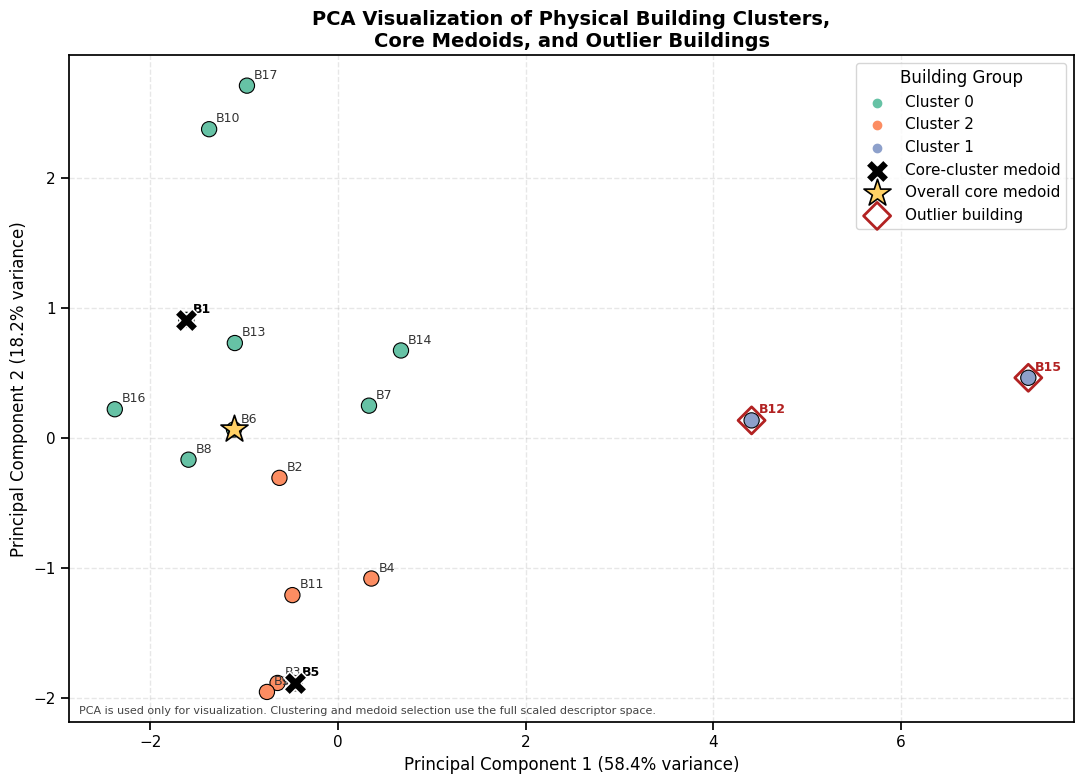

Variance explained by PC1: 58.36%
Variance explained by PC2: 18.24%
Total variance explained by the two-dimensional projection: 76.60%

Core-cluster medoid buildings: [1, 5]
Overall core-portfolio medoid: Building 6
Outlier buildings: [12, 15]

PCA figure saved to: C:\Users\Umair\Desktop\Ongoing_research\Summer\New folder\building_clustering_outputs\physical_building_clusters_pca.png


In [17]:
# --------------------------------------------------------------------------
# Visualize physical building clusters using two-dimensional PCA
# --------------------------------------------------------------------------

# PCA is used only for visualization.
# Clustering and medoid selection remain based on the complete
# robustly scaled physical-descriptor matrix, X_scaled.

if X_scaled.ndim != 2:
    raise ValueError(
        'X_scaled must be a two-dimensional matrix. '
        'Received shape: {}.'.format(
            X_scaled.shape
        )
    )

if X_scaled.shape[0] != len(BUILDING_IDS):
    raise ValueError(
        'X_scaled contains {} rows, but {} buildings were expected.'.format(
            X_scaled.shape[0],
            len(BUILDING_IDS)
        )
    )

if len(cluster_labels) != len(BUILDING_IDS):
    raise ValueError(
        'Expected {} cluster labels, but found {}.'.format(
            len(BUILDING_IDS),
            len(cluster_labels)
        )
    )

if not np.all(np.isfinite(X_scaled)):
    raise ValueError(
        'X_scaled contains NaN or infinite values.'
    )

if len(np.unique(cluster_labels)) != FINAL_K:
    raise ValueError(
        'The cluster-label array contains {} clusters, '
        'but FINAL_K is {}.'.format(
            len(np.unique(cluster_labels)),
            FINAL_K
        )
    )

if 'OUTLIER_BUILDINGS' not in globals():
    OUTLIER_BUILDINGS = [12, 15]


# --------------------------------------------------------------------------
# Fit PCA for visualization
# --------------------------------------------------------------------------

pca_model = PCA(
    n_components=2
)

X_pca = pca_model.fit_transform(
    X_scaled
)

explained_variance = (
    pca_model.explained_variance_ratio_
)

total_explained_variance = float(
    explained_variance.sum()
)


if not np.all(np.isfinite(X_pca)):
    raise ValueError(
        'PCA produced NaN or infinite coordinates.'
    )


# --------------------------------------------------------------------------
# Build the PCA plotting table
# --------------------------------------------------------------------------

plot_data = pd.DataFrame({
    'building_id':
        BUILDING_IDS,

    'PC1':
        X_pca[:, 0],

    'PC2':
        X_pca[:, 1],

    'cluster':
        cluster_labels.astype(int)
})


plot_data['cluster_label'] = plot_data[
    'cluster'
].apply(
    lambda value: 'Cluster {}'.format(
        int(value)
    )
)


plot_data['is_outlier'] = plot_data[
    'building_id'
].isin(
    OUTLIER_BUILDINGS
)


# Identify the core-cluster medoids from the updated medoid table.
core_medoid_buildings = (
    cluster_medoids_table[
        cluster_medoids_table[
            'cluster_role'
        ] == 'core_development'
    ][
        'selected_medoid_building'
    ]
    .astype(int)
    .tolist()
)


plot_data['is_core_medoid'] = plot_data[
    'building_id'
].isin(
    core_medoid_buildings
)


plot_data['is_overall_core_medoid'] = (
    plot_data['building_id']
    == overall_core_medoid_building
)


# --------------------------------------------------------------------------
# Create PCA scatter plot
# --------------------------------------------------------------------------

fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(11, 8)
)


sns.scatterplot(
    data=plot_data,
    x='PC1',
    y='PC2',
    hue='cluster_label',
    palette='Set2',
    s=120,
    edgecolor='black',
    linewidth=0.8,
    ax=ax,
    zorder=2
)


# --------------------------------------------------------------------------
# Annotate every building
# --------------------------------------------------------------------------

for _, row in plot_data.iterrows():
    building_id = int(
        row['building_id']
    )

    if row['is_outlier']:
        label_color = '#b22222'
        font_weight = 'bold'
    elif row['is_core_medoid']:
        label_color = 'black'
        font_weight = 'bold'
    else:
        label_color = '#333333'
        font_weight = 'normal'

    ax.annotate(
        'B{}'.format(building_id),
        xy=(
            row['PC1'],
            row['PC2']
        ),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9,
        fontweight=font_weight,
        color=label_color,
        zorder=5
    )


# --------------------------------------------------------------------------
# Highlight core-cluster medoids
# --------------------------------------------------------------------------

for building_id in core_medoid_buildings:
    position = BUILDING_IDS.index(
        building_id
    )

    ax.scatter(
        X_pca[position, 0],
        X_pca[position, 1],
        marker='X',
        s=280,
        color='black',
        edgecolor='white',
        linewidth=1.2,
        zorder=6,
        label='Core-cluster medoid'
    )


# --------------------------------------------------------------------------
# Highlight the overall core-portfolio medoid
# --------------------------------------------------------------------------

overall_core_position = BUILDING_IDS.index(
    overall_core_medoid_building
)

ax.scatter(
    X_pca[overall_core_position, 0],
    X_pca[overall_core_position, 1],
    marker='*',
    s=420,
    color='#ffd166',
    edgecolor='black',
    linewidth=1.2,
    zorder=7,
    label='Overall core medoid'
)


# --------------------------------------------------------------------------
# Highlight outlier buildings
# --------------------------------------------------------------------------

for outlier_index, building_id in enumerate(
    OUTLIER_BUILDINGS
):
    position = BUILDING_IDS.index(
        building_id
    )

    ax.scatter(
        X_pca[position, 0],
        X_pca[position, 1],
        marker='D',
        s=190,
        facecolor='none',
        edgecolor='#b22222',
        linewidth=2.0,
        zorder=6,
        label=(
            'Outlier building'
            if outlier_index == 0
            else None
        )
    )


# --------------------------------------------------------------------------
# Axis labels and interpretation warning
# --------------------------------------------------------------------------

ax.set_xlabel(
    'Principal Component 1 ({:.1f}% variance)'.format(
        100.0
        * explained_variance[0]
    )
)

ax.set_ylabel(
    'Principal Component 2 ({:.1f}% variance)'.format(
        100.0
        * explained_variance[1]
    )
)

ax.set_title(
    'PCA Visualization of Physical Building Clusters,\n'
    'Core Medoids, and Outlier Buildings',
    fontsize=14,
    fontweight='bold'
)

ax.grid(
    linestyle='--',
    alpha=0.30
)

ax.set_axisbelow(
    True
)


# --------------------------------------------------------------------------
# Remove duplicate legend entries
# --------------------------------------------------------------------------

legend_handles, legend_labels = (
    ax.get_legend_handles_labels()
)

unique_legend_entries = {}

for handle, label in zip(
    legend_handles,
    legend_labels
):
    if label and label not in unique_legend_entries:
        unique_legend_entries[label] = handle


ax.legend(
    unique_legend_entries.values(),
    unique_legend_entries.keys(),
    title='Building Group',
    loc='best',
    frameon=True
)


# Add a clarification inside the figure.
ax.text(
    0.01,
    0.01,
    (
        'PCA is used only for visualization. '
        'Clustering and medoid selection use the full '
        'scaled descriptor space.'
    ),
    transform=ax.transAxes,
    fontsize=8,
    color='#444444',
    verticalalignment='bottom'
)


plt.tight_layout()
plt.show()


# --------------------------------------------------------------------------
# Report PCA information
# --------------------------------------------------------------------------

print(
    'Variance explained by PC1: {:.2f}%'.format(
        100.0
        * explained_variance[0]
    )
)

print(
    'Variance explained by PC2: {:.2f}%'.format(
        100.0
        * explained_variance[1]
    )
)

print(
    'Total variance explained by the two-dimensional projection: '
    '{:.2f}%'.format(
        100.0
        * total_explained_variance
    )
)

print(
    '\nCore-cluster medoid buildings:',
    core_medoid_buildings
)

print(
    'Overall core-portfolio medoid: Building {}'.format(
        overall_core_medoid_building
    )
)

print(
    'Outlier buildings:',
    OUTLIER_BUILDINGS
)


if total_explained_variance < 0.70:
    print(
        '\nCAUTION: The first two principal components explain less '
        'than 70% of the total descriptor variance. Distances and '
        'apparent separation in this two-dimensional figure should '
        'not be interpreted as the complete physical relationship.'
    )


# --------------------------------------------------------------------------
# Save PCA coordinates and figure safely
# --------------------------------------------------------------------------

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


pca_output_table = plot_data.copy()

pca_output_table[
    'is_core_medoid'
] = pca_output_table[
    'is_core_medoid'
].astype(bool)

pca_output_table[
    'is_overall_core_medoid'
] = pca_output_table[
    'is_overall_core_medoid'
].astype(bool)


pca_table_path = (
    OUTPUT_DIR
    / 'building_pca_coordinates.csv'
)

try:
    pca_output_table.to_csv(
        pca_table_path,
        index=False
    )

except PermissionError:
    alternative_pca_table_path = (
        OUTPUT_DIR
        / 'building_pca_coordinates_new.csv'
    )

    pca_output_table.to_csv(
        alternative_pca_table_path,
        index=False
    )

    print(
        '\nWARNING: The original PCA-coordinate file could not be '
        'overwritten, probably because it is open in Excel.'
    )

    print(
        'PCA coordinates were saved instead to:',
        alternative_pca_table_path.resolve()
    )


figure_path = (
    OUTPUT_DIR
    / 'physical_building_clusters_pca.png'
)

try:
    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches='tight'
    )

except PermissionError:
    alternative_figure_path = (
        OUTPUT_DIR
        / 'physical_building_clusters_pca_new.png'
    )

    fig.savefig(
        alternative_figure_path,
        dpi=300,
        bbox_inches='tight'
    )

    print(
        '\nWARNING: The original PCA figure could not be overwritten.'
    )

    print(
        'The figure was saved instead to:',
        alternative_figure_path.resolve()
    )

else:
    print(
        '\nPCA figure saved to:',
        figure_path.resolve()
    )

## 18. Cluster-wise cyclic load and PV profiles

Ribbons show variation across cluster members, not statistical confidence intervals.


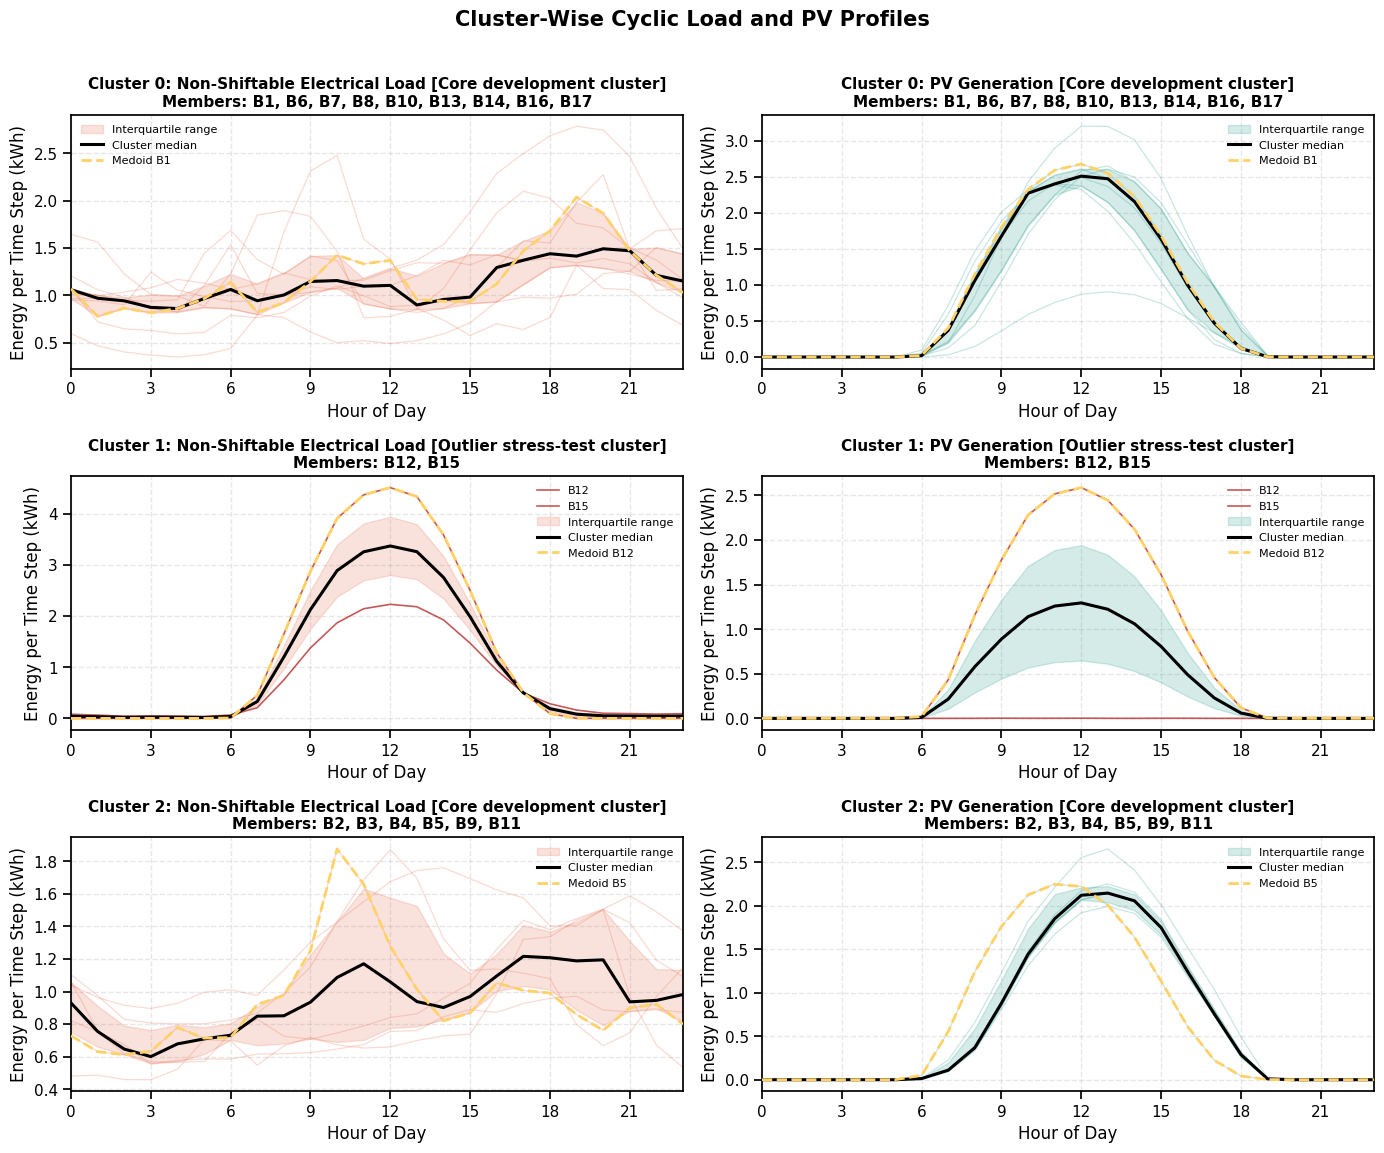

Cyclic-profile figure saved to: C:\Users\Umair\Desktop\Ongoing_research\Summer\New folder\building_clustering_outputs\cluster_cyclic_load_pv_profiles.png


In [18]:
# --------------------------------------------------------------------------
# Plot cluster-wise cyclic daily load and PV profiles
# --------------------------------------------------------------------------

def calculate_cyclic_profile(
    member_ids,
    variable,
    time_step_hours=1.0
):
    """Calculate cluster-level cyclic daily profiles.

    Each building is first reduced to its mean daily profile. The cluster
    median and interquartile range are then calculated across buildings.

    Parameters
    ----------
    member_ids : list of int
        Building identifiers belonging to one cluster.

    variable : str
        Key in raw_data, normally 'load' or 'pv'.

    time_step_hours : float
        Duration of one simulation time step in hours.

    Returns
    -------
    dict
        Cluster median, 25th percentile, 75th percentile, and individual
        building cyclic profiles.
    """

    if not member_ids:
        raise ValueError(
            'member_ids must contain at least one building.'
        )

    if variable not in ['load', 'pv']:
        raise ValueError(
            "variable must be either 'load' or 'pv'. "
            "Received: {!r}.".format(variable)
        )

    if (
        not np.isfinite(time_step_hours)
        or time_step_hours <= 0.0
    ):
        raise ValueError(
            'time_step_hours must be finite and greater than zero.'
        )

    steps_per_day = int(
        round(
            24.0 / time_step_hours
        )
    )

    if not np.isclose(
        steps_per_day * time_step_hours,
        24.0,
        rtol=1e-8,
        atol=1e-8
    ):
        raise ValueError(
            'TIME_STEP_HOURS={} does not produce an integer number '
            'of time steps per day.'.format(
                time_step_hours
            )
        )

    building_profiles = []
    valid_building_ids = []



    for building_id in member_ids:
        if building_id not in raw_data:
            raise KeyError(
                'raw_data does not contain Building {}.'.format(
                    building_id
                )
            )

        if variable not in raw_data[building_id]:
            raise KeyError(
                "raw_data[{}] does not contain variable {!r}.".format(
                    building_id,
                    variable
                )
            )

        values = np.asarray(
            raw_data[building_id][variable],
            dtype=float
        ).reshape(-1)




        if values.size == 0:
            raise ValueError(
                'Building {} has no data for variable {!r}.'.format(
                    building_id,
                    variable
                )
            )

        if not np.all(np.isfinite(values)):
            raise ValueError(
                'Building {} contains nonfinite values for '
                'variable {!r}.'.format(
                    building_id,
                    variable
                )
            )

        if values.min() < -EPSILON:
            raise ValueError(
                'Building {} contains negative physical values for '
                'variable {!r}.'.format(
                    building_id,
                    variable
                )
            )

        n_complete_days = (
            values.size
            // steps_per_day
        )

        if n_complete_days < 1:
            raise ValueError(
                'Building {} does not contain a complete day '
                'for variable {!r}.'.format(
                    building_id,
                    variable
                )
            )

        # Omit only an incomplete final day.
        n_complete_steps = (
            n_complete_days
            * steps_per_day
        )

        trimmed_values = values[
            :n_complete_steps
        ]

        daily_profiles = trimmed_values.reshape(
            n_complete_days,
            steps_per_day
        )

        # Each building contributes one mean cyclic profile, preventing
        # buildings with more observations from receiving greater weight.
        mean_building_profile = daily_profiles.mean(
            axis=0
        )

        building_profiles.append(
            mean_building_profile
        )

        valid_building_ids.append(
            int(building_id)
        )

    building_profiles = np.vstack(
        building_profiles
    )

    return {
        'building_ids':
            valid_building_ids,

        'individual_profiles':
            building_profiles,

        'median':
            np.median(
                building_profiles,
                axis=0
            ),

        'q25':
            np.quantile(
                building_profiles,
                0.25,
                axis=0
            ),

        'q75':
            np.quantile(
                building_profiles,
                0.75,
                axis=0
            ),

        'minimum':
            np.min(
                building_profiles,
                axis=0
            ),

        'maximum':
            np.max(
                building_profiles,
                axis=0
            ),

        'steps_per_day':
            steps_per_day,

        'number_of_buildings':
            len(valid_building_ids)
    }


# --------------------------------------------------------------------------
# Validate clustering information
# --------------------------------------------------------------------------

cluster_labels = np.asarray(
    cluster_labels,
    dtype=int
)

if len(cluster_labels) != len(BUILDING_IDS):
    raise ValueError(
        'Expected {} cluster labels, but found {}.'.format(
            len(BUILDING_IDS),
            len(cluster_labels)
        )
    )

cluster_ids = sorted(
    np.unique(cluster_labels)
)

if len(cluster_ids) != FINAL_K:
    raise ValueError(
        'Expected {} clusters, but found {} unique labels: {}.'.format(
            FINAL_K,
            len(cluster_ids),
            cluster_ids
        )
    )

if 'OUTLIER_BUILDINGS' not in globals():
    OUTLIER_BUILDINGS = [12, 15]

if 'OUTLIER_CLUSTER' not in globals():
    outlier_cluster_values = {
        int(
            cluster_labels[
                BUILDING_IDS.index(building_id)
            ]
        )
        for building_id in OUTLIER_BUILDINGS
    }

    if len(outlier_cluster_values) != 1:
        raise ValueError(
            'The declared outlier buildings do not belong to '
            'one common cluster.'
        )

    OUTLIER_CLUSTER = int(
        next(
            iter(outlier_cluster_values)
        )
    )


# --------------------------------------------------------------------------
# Define daily time axis
# --------------------------------------------------------------------------

steps_per_day = int(
    round(
        24.0 / TIME_STEP_HOURS
    )
)

time_of_day = (
    np.arange(steps_per_day)
    * TIME_STEP_HOURS
)


# --------------------------------------------------------------------------
# Create plotting layout
# --------------------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=FINAL_K,
    ncols=2,
    figsize=(
        14,
        3.8 * FINAL_K
    ),
    squeeze=False
)


plotting_variables = [
    {
        'variable': 'load',
        'title': 'Non-Shiftable Electrical Load',
        'color': '#e76f51'
    },
    {
        'variable': 'pv',
        'title': 'PV Generation',
        'color': '#2a9d8f'
    }
]


# --------------------------------------------------------------------------
# Plot each cluster
# --------------------------------------------------------------------------

profile_summary_records = []

for row_index, cluster_id in enumerate(
    cluster_ids
):
    members = [
        int(building_id)
        for building_id, label in zip(
            BUILDING_IDS,
            cluster_labels
        )
        if int(label) == int(cluster_id)
    ]

    if not members:
        raise ValueError(
            'Cluster {} contains no buildings.'.format(
                cluster_id
            )
        )

    cluster_role = (
        'Outlier stress-test cluster'
        if int(cluster_id) == int(OUTLIER_CLUSTER)
        else 'Core development cluster'
    )

    for column_index, plot_settings in enumerate(
        plotting_variables
    ):
        variable = plot_settings[
            'variable'
        ]

        profile_summary = calculate_cyclic_profile(
            member_ids=members,
            variable=variable,
            time_step_hours=TIME_STEP_HOURS
        )

        ax = axes[
            row_index,
            column_index
        ]

        # Plot individual building profiles using faint lines.
        for profile_index, building_profile in enumerate(
            profile_summary[
                'individual_profiles'
            ]
        ):
            building_id = profile_summary[
                'building_ids'
            ][profile_index]

            if building_id in OUTLIER_BUILDINGS:
                individual_color = '#b22222'
                individual_alpha = 0.75
                individual_width = 1.2
            else:
                individual_color = plot_settings[
                    'color'
                ]
                individual_alpha = 0.25
                individual_width = 0.9

            ax.plot(
                time_of_day,
                building_profile,
                color=individual_color,
                linewidth=individual_width,
                alpha=individual_alpha,
                label=(
                    'B{}'.format(building_id)
                    if len(members) <= 4
                    else None
                ),
                zorder=1
            )

        # Plot the interquartile range across building profiles.
        ax.fill_between(
            time_of_day,
            profile_summary['q25'],
            profile_summary['q75'],
            color=plot_settings['color'],
            alpha=0.20,
            label='Interquartile range',
            zorder=2
        )

        # Plot the cluster median.
        ax.plot(
            time_of_day,
            profile_summary['median'],
            color='black',
            linewidth=2.2,
            label='Cluster median',
            zorder=3
        )

        # Mark the cluster medoid if available.
        medoid_rows = cluster_medoids_table[
            cluster_medoids_table[
                'cluster'
            ] == cluster_id
        ]

        if not medoid_rows.empty:
            medoid_building = int(
                medoid_rows.iloc[0][
                    'selected_medoid_building'
                ]
            )

            if medoid_building in members:
                medoid_position = members.index(
                    medoid_building
                )

                medoid_profile = profile_summary[
                    'individual_profiles'
                ][
                    medoid_position
                ]

                ax.plot(
                    time_of_day,
                    medoid_profile,
                    color='#ffd166',
                    linewidth=2.0,
                    linestyle='--',
                    label='Medoid B{}'.format(
                        medoid_building
                    ),
                    zorder=4
                )

        ax.set_title(
            'Cluster {}: {} [{}]\nMembers: {}'.format(
                cluster_id,
                plot_settings['title'],
                cluster_role,
                ', '.join(
                    'B{}'.format(building_id)
                    for building_id in members
                )
            ),
            fontsize=11,
            fontweight='bold'
        )

        ax.set_xlabel(
            'Hour of Day'
        )

        ax.set_ylabel(
            'Energy per Time Step (kWh)'
        )

        ax.set_xlim(
            0.0,
            24.0 - TIME_STEP_HOURS
        )

        ax.xaxis.set_major_locator(
            ticker.MaxNLocator(
                nbins=8,
                integer=True
            )
        )

        ax.grid(
            linestyle='--',
            alpha=0.30
        )

        ax.set_axisbelow(
            True
        )

        # Remove duplicate legend entries.
        handles, labels = (
            ax.get_legend_handles_labels()
        )

        unique_entries = {}

        for handle, label in zip(
            handles,
            labels
        ):
            if (
                label
                and label not in unique_entries
            ):
                unique_entries[label] = handle

        ax.legend(
            unique_entries.values(),
            unique_entries.keys(),
            loc='best',
            frameon=False,
            fontsize=8
        )

        for time_index, time_value in enumerate(
            time_of_day
        ):
            profile_summary_records.append({
                'cluster':
                    int(cluster_id),

                'cluster_role':
                    cluster_role,

                'variable':
                    variable,

                'hour_of_day':
                    float(time_value),

                'cluster_median':
                    float(
                        profile_summary[
                            'median'
                        ][time_index]
                    ),

                'cluster_q25':
                    float(
                        profile_summary[
                            'q25'
                        ][time_index]
                    ),

                'cluster_q75':
                    float(
                        profile_summary[
                            'q75'
                        ][time_index]
                    ),

                'number_of_buildings':
                    int(
                        profile_summary[
                            'number_of_buildings'
                        ]
                    )
            })


fig.suptitle(
    'Cluster-Wise Cyclic Load and PV Profiles',
    fontsize=15,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.show()


# --------------------------------------------------------------------------
# Save profile summaries and figure
# --------------------------------------------------------------------------

cluster_profile_summary = pd.DataFrame(
    profile_summary_records
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


profile_output_path = (
    OUTPUT_DIR
    / 'cluster_cyclic_profile_summary.csv'
)

try:
    cluster_profile_summary.to_csv(
        profile_output_path,
        index=False
    )

except PermissionError:
    alternative_profile_path = (
        OUTPUT_DIR
        / 'cluster_cyclic_profile_summary_new.csv'
    )

    cluster_profile_summary.to_csv(
        alternative_profile_path,
        index=False
    )

    print(
        'WARNING: The original profile-summary file could not be '
        'overwritten, probably because it is open in Excel.'
    )

    print(
        'Profile summary saved instead to:',
        alternative_profile_path.resolve()
    )


figure_path = (
    OUTPUT_DIR
    / 'cluster_cyclic_load_pv_profiles.png'
)

try:
    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches='tight'
    )

except PermissionError:
    alternative_figure_path = (
        OUTPUT_DIR
        / 'cluster_cyclic_load_pv_profiles_new.png'
    )

    fig.savefig(
        alternative_figure_path,
        dpi=300,
        bbox_inches='tight'
    )

    print(
        'WARNING: The original cyclic-profile figure could not '
        'be overwritten.'
    )

    print(
        'Figure saved instead to:',
        alternative_figure_path.resolve()
    )

else:
    print(
        'Cyclic-profile figure saved to:',
        figure_path.resolve()
    )

## 19. Supplementary shape-normalized load analysis

This section answers a separate question: similarity of load chronology after magnitude is removed. Results support interpretation but do not determine the TD3 development panel.


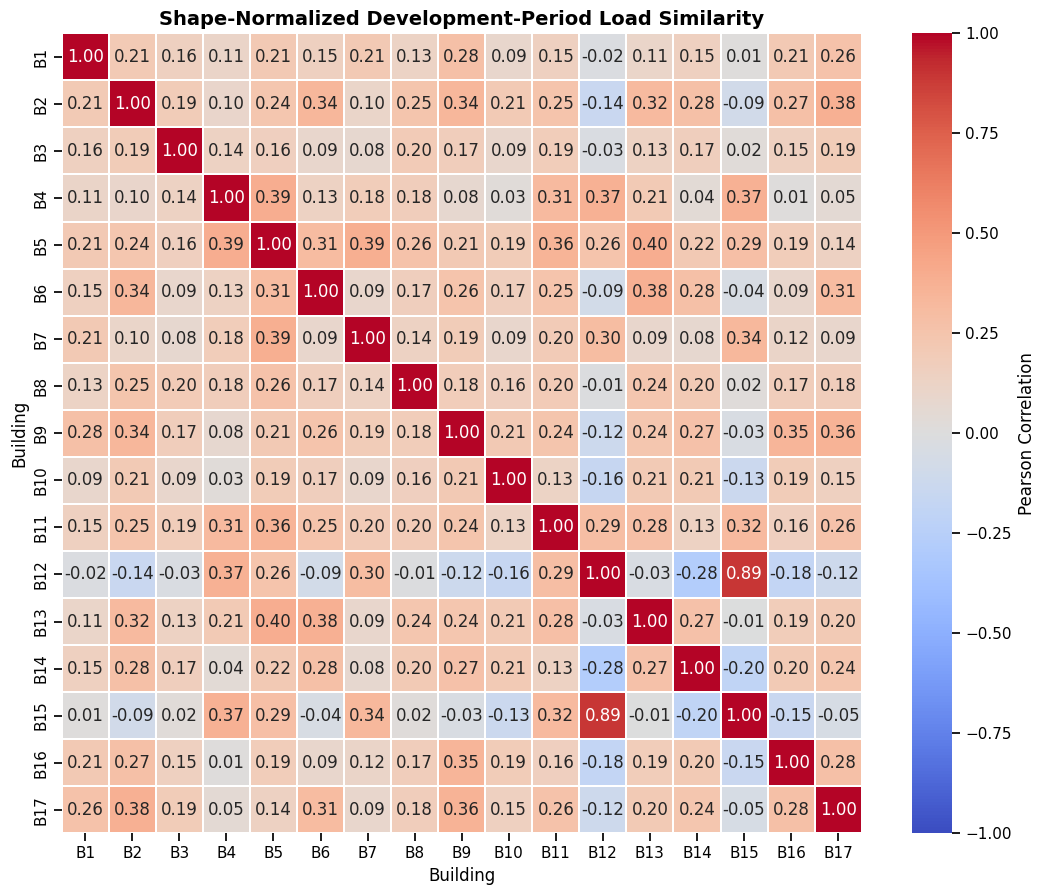

Three nearest load-shape neighbors for each building:


,building_id,neighbor_building,shape_distance,shape_correlation,neighbor_rank,same_physical_cluster,source_is_outlier,neighbor_is_outlier
0,1,9,105.4640,0.2751,1,False,False,False
1,1,17,106.3568,0.2628,2,True,False,False
2,1,16,109.8489,0.2136,3,True,False,False
3,2,17,97.6582,0.3784,1,False,False,False
4,2,9,100.5744,0.3408,2,True,False,False
5,2,6,100.7288,0.3387,3,False,False,False
6,3,8,110.9024,0.1984,1,False,False,False
7,3,2,111.4476,0.1905,2,True,False,False
8,3,17,111.5724,0.1887,3,False,False,False
9,4,5,96.6380,0.3914,1,True,False,False


Fraction of the top 3 load-shape neighbors that belong to the same physical cluster: 37.25%

Nearest load-shape neighbors of the outlier buildings:


,building_id,neighbor_building,shape_distance,shape_correlation,neighbor_rank,same_physical_cluster,source_is_outlier,neighbor_is_outlier
33,12,15,40.8671,0.8912,1,True,True,True
34,12,4,98.3399,0.3697,2,False,True,False
35,12,7,103.6607,0.2997,3,False,True,False
42,15,12,40.8671,0.8912,1,True,True,True
43,15,4,98.0991,0.3728,2,False,True,False
44,15,7,100.9463,0.3359,3,False,True,False



Load-shape heatmap saved to: C:\Users\Umair\Desktop\Ongoing_research\Summer\New folder\building_clustering_outputs\load_shape_correlation_heatmap.png


In [19]:
# --------------------------------------------------------------------------
# Supplementary analysis of shape-normalized load profiles
# --------------------------------------------------------------------------

# This analysis compares temporal load shapes after removing differences
# in mean load and magnitude. It supports interpretation but does not replace
# the physical-descriptor clustering used for TD3 building selection.

if 'OUTLIER_BUILDINGS' not in globals():
    OUTLIER_BUILDINGS = [12, 15]

if len(BUILDING_IDS) < 2:
    raise ValueError(
        'At least two buildings are required for load-shape analysis.'
    )

if len(cluster_labels) != len(BUILDING_IDS):
    raise ValueError(
        'Expected {} physical-cluster labels, but found {}.'.format(
            len(BUILDING_IDS),
            len(cluster_labels)
        )
    )

shape_normalized_load = {}
load_lengths = {}

for building_id in BUILDING_IDS:
    if building_id not in raw_data:
        raise KeyError(
            'raw_data does not contain Building {}.'.format(building_id)
        )

    if 'load' not in raw_data[building_id]:
        raise KeyError(
            "raw_data[{}] does not contain 'load'.".format(building_id)
        )

    load = np.asarray(
        raw_data[building_id]['load'],
        dtype=float
    ).reshape(-1)

    if load.size == 0:
        raise ValueError(
            'Building {} contains an empty load series.'.format(building_id)
        )

    if not np.all(np.isfinite(load)):
        raise ValueError(
            'Building {} contains nonfinite load values.'.format(building_id)
        )

    load_standard_deviation = float(load.std(ddof=0))

    if load_standard_deviation <= EPSILON:
        raise ValueError(
            'Building {} has a constant or nearly constant load profile.'.format(
                building_id
            )
        )

    normalized_load = zscore(
        load,
        ddof=0,
        nan_policy='raise'
    )

    normalized_load = np.asarray(
        normalized_load,
        dtype=float
    ).reshape(-1)

    if not np.all(np.isfinite(normalized_load)):
        raise ValueError(
            'Shape normalization generated nonfinite values for Building {}.'.format(
                building_id
            )
        )

    shape_normalized_load[building_id] = normalized_load
    load_lengths[building_id] = int(normalized_load.size)

if len(set(load_lengths.values())) != 1:
    raise ValueError(
        'Shape-normalized load lengths differ across buildings: {}'.format(
            load_lengths
        )
    )

X_shape = np.vstack([
    shape_normalized_load[building_id]
    for building_id in BUILDING_IDS
])

if X_shape.shape[0] != len(BUILDING_IDS):
    raise ValueError(
        'The shape matrix contains an unexpected number of buildings.'
    )

if not np.all(np.isfinite(X_shape)):
    raise ValueError(
        'The shape-normalized load matrix contains NaN or infinite values.'
    )

shape_correlation = np.corrcoef(X_shape)
expected_matrix_shape = (len(BUILDING_IDS), len(BUILDING_IDS))

if shape_correlation.shape != expected_matrix_shape:
    raise ValueError(
        'The load-shape correlation matrix has an unexpected shape: {}.'.format(
            shape_correlation.shape
        )
    )

if not np.all(np.isfinite(shape_correlation)):
    raise ValueError(
        'The load-shape correlation matrix contains NaN or infinite values.'
    )

if not np.allclose(
    np.diag(shape_correlation),
    1.0,
    rtol=1e-8,
    atol=1e-8
):
    raise ValueError(
        'The diagonal of the correlation matrix is not equal to one.'
    )

building_labels = [
    'B{}'.format(building_id)
    for building_id in BUILDING_IDS
]

fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(11, 9)
)

sns.heatmap(
    shape_correlation,
    xticklabels=building_labels,
    yticklabels=building_labels,
    cmap='coolwarm',
    center=0.0,
    vmin=-1.0,
    vmax=1.0,
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=0.25,
    cbar_kws={'label': 'Pearson Correlation'},
    ax=ax
)

ax.set_title(
    'Shape-Normalized Development-Period Load Similarity',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Building')
ax.set_ylabel('Building')
plt.tight_layout()
plt.show()

shape_distance = squareform(
    pdist(X_shape, metric='euclidean')
)

if shape_distance.shape != expected_matrix_shape:
    raise ValueError(
        'The load-shape distance matrix has an unexpected shape: {}.'.format(
            shape_distance.shape
        )
    )

if not np.all(np.isfinite(shape_distance)):
    raise ValueError(
        'The load-shape distance matrix contains NaN or infinite values.'
    )

if not np.allclose(
    shape_distance,
    shape_distance.T,
    rtol=1e-10,
    atol=1e-10
):
    raise ValueError(
        'The load-shape distance matrix is not symmetric.'
    )

neighbor_records = []

for building_position, building_id in enumerate(BUILDING_IDS):
    sorted_neighbor_positions = np.argsort(
        shape_distance[building_position]
    )
    neighbor_rank = 0

    for neighbor_position in sorted_neighbor_positions:
        if neighbor_position == building_position:
            continue

        neighbor_rank += 1
        neighbor_building = int(BUILDING_IDS[neighbor_position])

        neighbor_records.append({
            'building_id': int(building_id),
            'neighbor_building': neighbor_building,
            'shape_distance': float(
                shape_distance[building_position, neighbor_position]
            ),
            'shape_correlation': float(
                shape_correlation[building_position, neighbor_position]
            ),
            'neighbor_rank': int(neighbor_rank),
            'same_physical_cluster': bool(
                cluster_labels[building_position]
                == cluster_labels[neighbor_position]
            ),
            'source_is_outlier': bool(
                building_id in OUTLIER_BUILDINGS
            ),
            'neighbor_is_outlier': bool(
                neighbor_building in OUTLIER_BUILDINGS
            )
        })

nearest_neighbors = pd.DataFrame(neighbor_records)

if nearest_neighbors.empty:
    raise RuntimeError('The nearest-neighbor table is empty.')

top_neighbor_count = 3

top_nearest_neighbors = nearest_neighbors[
    nearest_neighbors['neighbor_rank'] <= top_neighbor_count
].sort_values([
    'building_id',
    'neighbor_rank'
]).reset_index(drop=True)

print('Three nearest load-shape neighbors for each building:')
display(
    top_nearest_neighbors.round({
        'shape_distance': 4,
        'shape_correlation': 4
    })
)

nearest_neighbor_agreement = top_nearest_neighbors[
    'same_physical_cluster'
].mean()

print(
    'Fraction of the top {} load-shape neighbors that belong '
    'to the same physical cluster: {:.2%}'.format(
        top_neighbor_count,
        nearest_neighbor_agreement
    )
)

outlier_neighbor_summary = top_nearest_neighbors[
    top_nearest_neighbors['source_is_outlier']
].copy()

if not outlier_neighbor_summary.empty:
    print('\nNearest load-shape neighbors of the outlier buildings:')
    display(
        outlier_neighbor_summary.round({
            'shape_distance': 4,
            'shape_correlation': 4
        })
    )

shape_correlation_table = pd.DataFrame(
    shape_correlation,
    index=BUILDING_IDS,
    columns=BUILDING_IDS
)
shape_correlation_table.index.name = 'building_id'

shape_distance_table = pd.DataFrame(
    shape_distance,
    index=BUILDING_IDS,
    columns=BUILDING_IDS
)
shape_distance_table.index.name = 'building_id'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

shape_output_tables = {
    'load_shape_correlation_matrix.csv': shape_correlation_table.reset_index(),
    'load_shape_distance_matrix.csv': shape_distance_table.reset_index(),
    'load_shape_nearest_neighbors.csv': nearest_neighbors,
    'load_shape_top_three_neighbors.csv': top_nearest_neighbors
}

for filename, output_table in shape_output_tables.items():
    output_path = OUTPUT_DIR / filename

    try:
        output_table.to_csv(output_path, index=False)
    except PermissionError:
        alternative_output_path = (
            OUTPUT_DIR / filename.replace('.csv', '_new.csv')
        )
        output_table.to_csv(alternative_output_path, index=False)
        print(
            'WARNING: {} could not be overwritten. Saved as {}.'.format(
                filename,
                alternative_output_path.name
            )
        )

figure_output_path = OUTPUT_DIR / 'load_shape_correlation_heatmap.png'

try:
    fig.savefig(
        figure_output_path,
        dpi=300,
        bbox_inches='tight'
    )
except PermissionError:
    alternative_figure_path = (
        OUTPUT_DIR / 'load_shape_correlation_heatmap_new.png'
    )
    fig.savefig(
        alternative_figure_path,
        dpi=300,
        bbox_inches='tight'
    )
    print(
        'WARNING: Heatmap saved instead to:',
        alternative_figure_path.resolve()
    )
else:
    print('\nLoad-shape heatmap saved to:', figure_output_path.resolve())


## 20. Final development panel and exports

Use all cluster medoids for robust multi-building TD3 tuning. If only one building is computationally possible, use the overall portfolio medoid and disclose the limitation.


In [20]:
# --------------------------------------------------------------------------
# Finalize and export clustering results
# --------------------------------------------------------------------------

from datetime import datetime


# --------------------------------------------------------------------------
# Validate the essential analysis objects
# --------------------------------------------------------------------------

required_objects = [
    'descriptors',
    'cluster_assignments',
    'cluster_quality',
    'cluster_medoids_table',
    'cluster_labels',
    'SELECTED_FEATURES',
    'FINAL_K',
    'overall_medoid_building',
    'overall_core_medoid_building',
    'initialization_stability',
    'algorithm_agreement_ari',
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise NameError(
        'The following required analysis objects are unavailable: '
        '{}'.format(missing_objects)
    )


# --------------------------------------------------------------------------
# Define and validate outlier information
# --------------------------------------------------------------------------

if 'OUTLIER_BUILDINGS' not in globals():
    OUTLIER_BUILDINGS = [12, 15]

if 'OUTLIER_CLUSTER' not in globals():
    outlier_cluster_labels = set()

    for building_id in OUTLIER_BUILDINGS:
        building_position = BUILDING_IDS.index(building_id)

        outlier_cluster_labels.add(
            int(cluster_labels[building_position])
        )

    if len(outlier_cluster_labels) != 1:
        raise ValueError(
            'Buildings 12 and 15 do not belong to one common cluster. '
            'Observed cluster labels: {}'.format(
                sorted(outlier_cluster_labels)
            )
        )

    OUTLIER_CLUSTER = int(
        list(outlier_cluster_labels)[0]
    )


# --------------------------------------------------------------------------
# Treat day-bootstrap analysis as optional during notebook development
# --------------------------------------------------------------------------

if 'bootstrap_stability' in globals():
    bootstrap_completed = True

    if len(bootstrap_stability) == 0:
        raise ValueError(
            'bootstrap_stability exists but contains no values.'
        )

    bootstrap_values = np.asarray(
        bootstrap_stability,
        dtype=float
    )

    if not np.all(np.isfinite(bootstrap_values)):
        raise ValueError(
            'bootstrap_stability contains NaN or infinite values.'
        )

    bootstrap_count = int(
        len(bootstrap_values)
    )

    bootstrap_ari_mean = float(
        np.mean(bootstrap_values)
    )

    bootstrap_ari_median = float(
        np.median(bootstrap_values)
    )

    bootstrap_ari_std = float(
        np.std(
            bootstrap_values,
            ddof=1
        )
    ) if bootstrap_count > 1 else 0.0

    bootstrap_ari_minimum = float(
        np.min(bootstrap_values)
    )

    bootstrap_ari_maximum = float(
        np.max(bootstrap_values)
    )

else:
    bootstrap_completed = False
    bootstrap_count = 0
    bootstrap_ari_mean = None
    bootstrap_ari_median = None
    bootstrap_ari_std = None
    bootstrap_ari_minimum = None
    bootstrap_ari_maximum = None

    print(
        'WARNING: Day-bootstrap stability analysis has not been run.'
    )

    print(
        'Bootstrap metadata will be saved as null. Run the '
        'day-bootstrap cell before freezing the final development panel.'
    )


# --------------------------------------------------------------------------
# Validate the medoid table
# --------------------------------------------------------------------------

required_medoid_columns = [
    'cluster',
    'cluster_role',
    'selected_medoid_building',
]

missing_medoid_columns = [
    column
    for column in required_medoid_columns
    if column not in cluster_medoids_table.columns
]

if missing_medoid_columns:
    raise KeyError(
        'cluster_medoids_table is missing columns: {}'.format(
            missing_medoid_columns
        )
    )


# --------------------------------------------------------------------------
# Create the primary multi-building TD3 development panel
# --------------------------------------------------------------------------

development_panel = cluster_medoids_table.loc[
    cluster_medoids_table['cluster_role']
    == 'core_development'
].copy()

development_panel = development_panel.reset_index(
    drop=True
)

if development_panel.empty:
    raise ValueError(
        'No core-cluster medoids were identified.'
    )

development_panel = development_panel.merge(
    descriptors.reset_index(),
    left_on='selected_medoid_building',
    right_on='building_id',
    how='left',
    validate='one_to_one'
)

if development_panel['building_id'].isna().any():
    raise ValueError(
        'One or more core medoids could not be matched '
        'to the physical descriptor table.'
    )

development_panel['is_overall_core_medoid'] = (
    development_panel['selected_medoid_building'].astype(int)
    == int(overall_core_medoid_building)
)

development_panel['recommended_use'] = (
    'primary_td3_hyperparameter_development'
)


print('Primary TD3 development panel:')

display(development_panel)


print(
    'Single-building fallback: Building {}'.format(
        overall_core_medoid_building
    )
)

print(
    'Outlier stress-test building: Building 12'
)

print(
    'Additional outlier retained in transfer matrix: Building 15'
)


# --------------------------------------------------------------------------
# Create the complete building assignment table
# --------------------------------------------------------------------------

final_assignments = descriptors.join(
    cluster_assignments,
    how='inner'
).reset_index()

if final_assignments.shape[0] != len(BUILDING_IDS):
    raise ValueError(
        'Expected {} building-assignment rows but found {}.'.format(
            len(BUILDING_IDS),
            final_assignments.shape[0]
        )
    )

if final_assignments['building_id'].duplicated().any():
    raise ValueError(
        'The final assignment table contains duplicated building IDs.'
    )


medoid_map = {}

cluster_role_map = {}

for _, row in cluster_medoids_table.iterrows():
    cluster_id = int(row['cluster'])

    medoid_map[cluster_id] = int(
        row['selected_medoid_building']
    )

    cluster_role_map[cluster_id] = str(
        row['cluster_role']
    )


final_assignments['cluster_role'] = (
    final_assignments['cluster']
    .map(cluster_role_map)
)

if final_assignments['cluster_role'].isna().any():
    raise ValueError(
        'At least one cluster could not be assigned a cluster role.'
    )


final_assignments['is_cluster_medoid'] = [
    int(building_id) == medoid_map[int(cluster_id)]
    for building_id, cluster_id in zip(
        final_assignments['building_id'],
        final_assignments['cluster']
    )
]


final_assignments['is_declared_outlier'] = (
    final_assignments['building_id']
    .isin(OUTLIER_BUILDINGS)
)


final_assignments[
    'is_overall_full_portfolio_medoid'
] = (
    final_assignments['building_id']
    == int(overall_medoid_building)
)


final_assignments[
    'is_overall_core_portfolio_medoid'
] = (
    final_assignments['building_id']
    == int(overall_core_medoid_building)
)


core_medoid_buildings = (
    development_panel['selected_medoid_building']
    .astype(int)
    .tolist()
)


final_assignments[
    'is_primary_td3_development_building'
] = (
    final_assignments['building_id']
    .isin(core_medoid_buildings)
)


final_assignments[
    'is_outlier_stress_test_candidate'
] = (
    final_assignments['building_id']
    .isin(OUTLIER_BUILDINGS)
)


print('\nFinal building assignments:')

display(final_assignments)


# --------------------------------------------------------------------------
# Create a compact methodological selection table
# --------------------------------------------------------------------------

selection_records = []


for _, row in development_panel.iterrows():
    selection_records.append({
        'building_id':
            int(row['selected_medoid_building']),

        'cluster':
            int(row['cluster']),

        'selection_role':
            'core_cluster_medoid',

        'recommended_use':
            'primary_td3_hyperparameter_development'
    })


selection_records.append({
    'building_id':
        int(overall_core_medoid_building),

    'cluster':
        int(
            final_assignments.loc[
                final_assignments['building_id']
                == overall_core_medoid_building,
                'cluster'
            ].iloc[0]
        ),

    'selection_role':
        'overall_core_portfolio_medoid',

    'recommended_use':
        'single_building_fallback'
})


selection_records.append({
    'building_id': 12,

    'cluster':
        int(
            final_assignments.loc[
                final_assignments['building_id'] == 12,
                'cluster'
            ].iloc[0]
        ),

    'selection_role':
        'outlier_building',

    'recommended_use':
        'outlier_stress_test'
})


selection_records.append({
    'building_id': 15,

    'cluster':
        int(
            final_assignments.loc[
                final_assignments['building_id'] == 15,
                'cluster'
            ].iloc[0]
        ),

    'selection_role':
        'outlier_building',

    'recommended_use':
        'final_transfer_matrix'
})


methodological_selection = pd.DataFrame(
    selection_records
)

methodological_selection = (
    methodological_selection
    .drop_duplicates(
        subset=[
            'building_id',
            'selection_role'
        ]
    )
    .sort_values([
        'selection_role',
        'building_id'
    ])
    .reset_index(drop=True)
)


print('\nMethodological building-selection summary:')

display(methodological_selection)


# --------------------------------------------------------------------------
# Safe export functions
# --------------------------------------------------------------------------

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

timestamp = datetime.now().strftime(
    '%Y%m%d_%H%M%S'
)


def save_csv_safely(
    dataframe,
    filename,
    include_index=False
):
    """Save a CSV and use a timestamp if the original file is locked."""

    output_path = OUTPUT_DIR / filename

    try:
        dataframe.to_csv(
            output_path,
            index=include_index
        )

        print('Saved:', output_path.resolve())

        return output_path

    except PermissionError:
        alternative_filename = filename.replace(
            '.csv',
            '_{}.csv'.format(timestamp)
        )

        alternative_path = (
            OUTPUT_DIR
            / alternative_filename
        )

        dataframe.to_csv(
            alternative_path,
            index=include_index
        )

        print(
            'WARNING: {} could not be overwritten, probably '
            'because it is open in Excel.'.format(filename)
        )

        print('Saved instead:', alternative_path.resolve())

        return alternative_path


def save_json_safely(
    data,
    filename
):
    """Save JSON and use a timestamp if the original file is locked."""

    output_path = OUTPUT_DIR / filename

    try:
        with open(
            output_path,
            'w',
            encoding='utf-8'
        ) as stream:
            json.dump(
                data,
                stream,
                indent=2
            )

        print('Saved:', output_path.resolve())

        return output_path

    except PermissionError:
        alternative_filename = filename.replace(
            '.json',
            '_{}.json'.format(timestamp)
        )

        alternative_path = (
            OUTPUT_DIR
            / alternative_filename
        )

        with open(
            alternative_path,
            'w',
            encoding='utf-8'
        ) as stream:
            json.dump(
                data,
                stream,
                indent=2
            )

        print(
            'WARNING: {} could not be overwritten.'.format(
                filename
            )
        )

        print('Saved instead:', alternative_path.resolve())

        return alternative_path


# --------------------------------------------------------------------------
# Export primary result tables
# --------------------------------------------------------------------------

save_csv_safely(
    final_assignments,
    'building_cluster_assignments.csv'
)

save_csv_safely(
    cluster_quality,
    'cluster_number_quality.csv'
)

save_csv_safely(
    cluster_medoids_table,
    'cluster_medoids_and_roles.csv'
)

save_csv_safely(
    development_panel,
    'core_td3_development_panel.csv'
)

save_csv_safely(
    methodological_selection,
    'methodological_building_selection.csv'
)


# Export optional tables only when available.
if 'nearest_neighbors' in globals():
    save_csv_safely(
        nearest_neighbors,
        'load_shape_nearest_neighbors.csv'
    )

if 'top_nearest_neighbors' in globals():
    save_csv_safely(
        top_nearest_neighbors,
        'load_shape_top_three_neighbors.csv'
    )

if 'overall_medoid_ranking' in globals():
    save_csv_safely(
        overall_medoid_ranking,
        'full_portfolio_medoid_ranking.csv'
    )

if 'core_medoid_ranking' in globals():
    save_csv_safely(
        core_medoid_ranking,
        'core_portfolio_medoid_ranking.csv'
    )

if 'outlier_stress_test_candidates' in globals():
    save_csv_safely(
        outlier_stress_test_candidates,
        'outlier_stress_test_candidates.csv'
    )


# --------------------------------------------------------------------------
# Construct complete reproducibility metadata
# --------------------------------------------------------------------------

metadata = {
    'dataset': {
        'data_path':
            str(DATA_PATH),

        'schema_path':
            str(SCHEMA_PATH),

        'building_ids': [
            int(building_id)
            for building_id in BUILDING_IDS
        ],

        'development_start':
            int(DEVELOPMENT_START),

        'development_end':
            int(DEVELOPMENT_END),

        'development_time_steps':
            int(
                DEVELOPMENT_END
                - DEVELOPMENT_START
                + 1
            ),

        'time_step_hours':
            float(TIME_STEP_HOURS),

        'load_column':
            str(LOAD_COLUMN),

        'pv_column':
            str(PV_COLUMN),

        'pv_conversion':
            (
                'W/kW profile multiplied by PV nominal power in kW, '
                'multiplied by time-step duration in hours, '
                'and divided by 1000.'
            )
    },

    'clustering': {
        'method':
            'KMeans',

        'selected_features': [
            str(feature)
            for feature in SELECTED_FEATURES
        ],

        'robust_scaling':
            True,

        'robust_scaling_quantile_range': [
            25.0,
            75.0
        ],

        'evaluated_k_values': [
            int(value)
            for value in K_VALUES
        ],

        'final_k':
            int(FINAL_K),

        'random_state':
            int(RANDOM_STATE),

        'kmeans_n_init':
            int(KMEANS_N_INIT),

        'kmeans_max_iter':
            int(KMEANS_MAX_ITER),

        'redundancy_threshold':
            float(REDUNDANCY_THRESHOLD)
    },

    'building_selection': {
        'outlier_buildings': [
            int(building_id)
            for building_id in OUTLIER_BUILDINGS
        ],

        'outlier_cluster':
            int(OUTLIER_CLUSTER),

        'cluster_medoids': {
            str(cluster_id): int(building_id)
            for cluster_id, building_id
            in medoid_map.items()
        },

        'core_cluster_medoids':
            core_medoid_buildings,

        'overall_full_portfolio_medoid':
            int(overall_medoid_building),

        'overall_core_portfolio_medoid':
            int(overall_core_medoid_building),

        'recommended_outlier_stress_test':
            12,

        'methodological_note':
            (
                'Core-cluster medoids are used for primary TD3 '
                'hyperparameter development. Building 12 is used '
                'as an outlier stress test. Buildings 12 and 15 '
                'remain included in final source-policy training '
                'and directed zero-shot transfer evaluation.'
            )
    },

    'stability': {
        'initialization_stability':
            initialization_stability,

        'day_bootstrap_completed':
            bool(bootstrap_completed),

        'number_of_day_bootstraps':
            int(bootstrap_count),

        'day_bootstrap_ari_mean':
            bootstrap_ari_mean,

        'day_bootstrap_ari_median':
            bootstrap_ari_median,

        'day_bootstrap_ari_std':
            bootstrap_ari_std,

        'day_bootstrap_ari_minimum':
            bootstrap_ari_minimum,

        'day_bootstrap_ari_maximum':
            bootstrap_ari_maximum,

        'kmeans_hierarchical_agreement_ari':
            float(algorithm_agreement_ari)
    },

    'td3_development': {
        'multi_building_panel':
            core_medoid_buildings,

        'single_building_fallback':
            int(overall_core_medoid_building),

        'outlier_stress_test':
            12,

        'all_buildings_retained_for_final_transfer':
            True
    }
}


# --------------------------------------------------------------------------
# Save metadata
# --------------------------------------------------------------------------

save_json_safely(
    metadata,
    'clustering_metadata.json'
)


# --------------------------------------------------------------------------
# Final summary
# --------------------------------------------------------------------------

print('\nSaved clustering outputs:')

for item in sorted(
    OUTPUT_DIR.iterdir()
):
    print('  -', item.name)


print('\nFinal methodological recommendation:')

print(
    '  Primary TD3 development panel:',
    core_medoid_buildings
)

print(
    '  Single-building fallback: Building {}'.format(
        overall_core_medoid_building
    )
)

print(
    '  Outlier stress test: Building 12'
)

print(
    '  Final zero-shot transfer analysis: all 17 buildings'
)

if not bootstrap_completed:
    print(
        '\nIMPORTANT: Run the day-bootstrap stability cell before '
        'freezing the final TD3 development panel.'
    )

Bootstrap metadata will be saved as null. Run the day-bootstrap cell before freezing the final development panel.
Primary TD3 development panel:


,cluster,cluster_role,cluster_size,cluster_members,selected_medoid_building,all_tied_medoid_candidates,number_of_tied_medoid_candidates,minimum_total_within_cluster_distance,mean_pairwise_within_cluster_distance,building_id,total_load_kwh,mean_load_kwh,peak_load_kwh,load_std_kwh,load_cv,load_factor,total_pv_kwh,mean_pv_kwh,peak_pv_kwh,pv_to_load_ratio,direct_pv_self_consumption_kwh,direct_pv_self_consumption_rate,pv_surplus_frequency,total_pv_surplus_kwh,pv_surplus_fraction,mean_net_demand_kwh,net_demand_std_kwh,net_demand_cv,peak_positive_net_demand_kwh,baseline_import_kwh,baseline_export_kwh,baseline_export_frequency,battery_capacity_kwh,battery_nominal_power_kw,battery_capacity_to_daily_load,battery_capacity_to_pv_surplus,battery_power_to_peak_load,battery_power_to_peak_net_demand,is_overall_core_medoid,recommended_use
0,0,core_development,9,"B1, B6, B7, B8, B10, B13, B14, B16, B17",1,B1,1,15.224350,2.49684,1,9004.354126,1.173665,7.987483,0.948096,0.807808,0.146938,6106.823059,0.795988,3.90500,0.678208,2938.864320,0.481243,0.288452,3167.958739,0.518757,0.377676,1.496376,1.243327,7.980433,6065.489806,3167.958739,0.288452,6.4,5.0,0.227209,0.64580,0.625979,0.626532,False,primary_td3_hyperparameter_development
1,2,core_development,6,"B2, B3, B4, B5, B9, B11",5,B5,1,9.813854,2.30911,5,7276.756677,0.948482,4.938767,0.770143,0.811973,0.192048,5082.176943,0.662432,3.27315,0.698412,3112.004623,0.612337,0.297445,1970.172320,0.387663,0.286051,1.033283,1.292167,4.938767,4164.752053,1970.172320,0.297445,6.4,5.0,0.281151,1.03842,1.012399,1.012399,False,primary_td3_hyperparameter_development


Single-building fallback: Building 6
Outlier stress-test building: Building 12
Additional outlier retained in transfer matrix: Building 15

Final building assignments:


,building_id,total_load_kwh,mean_load_kwh,peak_load_kwh,load_std_kwh,load_cv,load_factor,total_pv_kwh,mean_pv_kwh,peak_pv_kwh,pv_to_load_ratio,direct_pv_self_consumption_kwh,direct_pv_self_consumption_rate,pv_surplus_frequency,total_pv_surplus_kwh,pv_surplus_fraction,mean_net_demand_kwh,net_demand_std_kwh,net_demand_cv,peak_positive_net_demand_kwh,baseline_import_kwh,baseline_export_kwh,baseline_export_frequency,battery_capacity_kwh,battery_nominal_power_kw,battery_capacity_to_daily_load,battery_capacity_to_pv_surplus,battery_power_to_peak_load,battery_power_to_peak_net_demand,cluster,cluster_role,is_cluster_medoid,is_declared_outlier,is_overall_full_portfolio_medoid,is_overall_core_portfolio_medoid,is_primary_td3_development_building,is_outlier_stress_test_candidate
0,1,9004.354126,1.173665,7.987483,0.948096,0.807808,0.146938,6106.823059,0.795988,3.905000,0.678208,2938.864320,0.481243,0.288452,3167.958739,0.518757,0.377676,1.496376,1.243327,7.980433,6065.489806,3167.958739,0.288452,6.4,5.0,0.227209,0.645800,0.625979,0.626532,0,core_development,True,False,False,False,True,False
1,2,7640.261498,0.995863,6.843133,0.797536,0.800849,0.145527,4457.737524,0.581040,3.144333,0.583454,2136.311859,0.479237,0.269030,2321.425665,0.520763,0.414823,1.205689,1.182057,5.847750,5503.949639,2321.425665,0.269030,6.4,5.0,0.267774,0.881298,0.730659,0.855030,2,core_development,False,False,False,False,False,False
2,3,5828.424636,0.759701,6.101333,0.748087,0.984712,0.124514,4773.681049,0.622221,3.374850,0.819035,1931.541705,0.404623,0.306439,2842.139344,0.595377,0.137480,1.158626,1.319030,4.606917,3896.882931,2842.139344,0.306439,6.4,5.0,0.351015,0.719833,0.819493,1.085325,2,core_development,False,False,False,False,False,False
3,4,8306.296037,1.082677,5.905858,0.780062,0.720494,0.183323,5010.708743,0.653116,3.530183,0.603242,3509.891553,0.700478,0.227972,1500.817190,0.299522,0.429560,0.969815,1.181540,4.860450,4796.404484,1500.817190,0.227972,6.4,5.0,0.246303,1.363168,0.846617,1.028711,2,core_development,False,False,False,False,False,False
4,5,7276.756677,0.948482,4.938767,0.770143,0.811973,0.192048,5082.176943,0.662432,3.273150,0.698412,3112.004623,0.612337,0.297445,1970.172320,0.387663,0.286051,1.033283,1.292167,4.938767,4164.752053,1970.172320,0.297445,6.4,5.0,0.281151,1.038420,1.012399,1.012399,2,core_development,True,False,False,False,True,False
5,6,8800.962113,1.147154,6.790633,0.920183,0.802145,0.168932,5441.567797,0.709276,3.521083,0.618292,2514.705316,0.462129,0.282716,2926.862481,0.537871,0.437877,1.431990,1.192455,6.137750,6286.256797,2926.862481,0.282716,6.4,5.0,0.232459,0.698997,0.736308,0.814631,0,core_development,False,False,True,True,False,False
6,7,7193.362873,0.937612,7.239833,1.191100,1.270355,0.129507,5938.885148,0.774099,3.822533,0.825606,2982.238479,0.502155,0.250912,2956.646668,0.497845,0.163514,1.359210,1.454826,6.904983,4211.124394,2956.646668,0.250912,6.4,5.0,0.284410,0.691955,0.690624,0.724115,0,core_development,False,False,False,False,False,False
7,8,7244.940457,0.944335,7.268183,0.844010,0.893760,0.129927,5682.506014,0.740681,3.556083,0.784341,2441.258400,0.429609,0.311001,3241.247614,0.570391,0.203654,1.351315,1.288674,7.268183,4803.682056,3241.247614,0.310871,6.4,5.0,0.282386,0.631197,0.687930,0.687930,0,core_development,False,False,False,False,False,False
8,9,5952.115107,0.775823,5.191617,0.700391,0.902771,0.149438,4731.195545,0.616683,3.344183,0.794876,1762.083705,0.372439,0.295229,2969.111840,0.627561,0.159140,1.196744,1.282474,4.989117,4190.031402,2969.111840,0.295229,6.4,5.0,0.343721,0.689050,0.963091,1.002181,2,core_development,False,False,False,False,False,False
9,10,11136.356080,1.451558,8.601900,1.349396,0.929619,0.168749,6022.477873,0.784995,4.118100,0.540794,2537.130616,0.421277,0.273592,3485.347257,0.578723,0.666564,1.889495,1.199563,8.601900,8599.225464,3485.347257,0.273592,6.4,5.0,0.183711,0.586991,0.581267,0.581267,0,core_development,False,False,False,False,False,False



Methodological building-selection summary:


,building_id,cluster,selection_role,recommended_use
0,1,0,core_cluster_medoid,primary_td3_hyperparameter_development
1,5,2,core_cluster_medoid,primary_td3_hyperparameter_development
2,12,1,outlier_building,outlier_stress_test
3,15,1,outlier_building,final_transfer_matrix
4,6,0,overall_core_portfolio_medoid,single_building_fallback


Saved: C:\Users\Umair\Desktop\Ongoing_research\Summer\New folder\building_clustering_outputs\building_cluster_assignments.csv
Saved: C:\Users\Umair\Desktop\Ongoing_research\Summer\New folder\building_clustering_outputs\cluster_number_quality.csv
Saved: C:\Users\Umair\Desktop\Ongoing_research\Summer\New folder\building_clustering_outputs\cluster_medoids_and_roles.csv
Saved: C:\Users\Umair\Desktop\Ongoing_research\Summer\New folder\building_clustering_outputs\core_td3_development_panel.csv
Saved: C:\Users\Umair\Desktop\Ongoing_research\Summer\New folder\building_clustering_outputs\methodological_building_selection.csv
Saved: C:\Users\Umair\Desktop\Ongoing_research\Summer\New folder\building_clustering_outputs\load_shape_nearest_neighbors.csv
Saved: C:\Users\Umair\Desktop\Ongoing_research\Summer\New folder\building_clustering_outputs\load_shape_top_three_neighbors.csv
Saved: C:\Users\Umair\Desktop\Ongoing_research\Summer\New folder\building_clustering_outputs\full_portfolio_medoid_ranking

## 21. Final methodological checklist

Before TD3 tuning, verify:

- [ ] The load column maps to the CityLearn non-shiftable electrical load.
- [ ] The PV column is actual building PV energy, or a per-kW profile has been converted using installed capacity.
- [ ] PV uses a positive physical sign convention.
- [ ] Only the development interval was used.
- [ ] Battery-relative descriptors were included if battery settings differ.
- [ ] Redundant descriptors were reviewed physically.
- [ ] Final K is supported by indices, cluster sizes, interpretation, and stability.
- [ ] Initialization and day-bootstrap stability are acceptable.
- [ ] K-means and hierarchical clustering do not show unexplained disagreement.
- [ ] Representatives are true medoids in the full clustering space.
- [ ] PCA was used only for visualization.
- [ ] No TD3 reward, trained-policy performance, transfer result, or final test data influenced selection.
- [ ] Assignments and metadata were frozen before TD3 hyperparameter optimization.

### TD3 use

Tune the discount factor and subsequent TD3 parameters across all selected cluster medoids. Use robust validation performance across the development panel, seed variability, and failed-run rate. Keep the final TD3 configuration fixed for all 17 source buildings and the directed zero-shot transfer matrix.
